In [ ]:
# TASK 1

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import psycopg2
import psycopg2.extras
import json
import os

credentials = "Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        try:
            db = create_engine('postgresql+psycopg2://'+db_user+':'+db_pw+'@'+host+'/'+default_db, echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result


In [ ]:
db, conn = pgconnect(credentials)

Connected successfully.


In [ ]:
query(conn, "select PostGIS_Version()")

,postgis_version
0,3.4 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


In [ ]:
## SA2 Regions dataset

sa2 = gpd.read_file("SA2_2021_AUST_SHP_GDA2020")
sa2

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.21800 -35.3..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.19970 -35.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2468,901031003,Jervis Bay,0,No change,90103,Jervis Bay,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,67.2296,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((150.69567 -35.18295, 150.69556..."
2469,901041004,Norfolk Island,0,No change,90104,Norfolk Island,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,38.6510,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((167.96325 -29.07212, 167.96326..."
2470,997979799,Migratory - Offshore - Shipping (OT),0,No change,99797,Migratory - Offshore - Shipping (OT),997,Migratory - Offshore - Shipping (OT),99799,Migratory - Offshore - Shipping (OT),9,Other Territories,AUS,Australia,NaN,http://linked.data.gov.au/dataset/asgsed3/SA2/...,None
2471,999999499,No usual address (OT),0,No change,99999,No usual address (OT),999,No usual address (OT),99499,No usual address (OT),9,Other Territories,AUS,Australia,NaN,http://linked.data.gov.au/dataset/asgsed3/SA2/...,None


In [ ]:
srid = 4326

def create_wkt_element(geom, srid):
    if geom is None:
        return None
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

sa2 = sa2[sa2['geometry'] != 'None']
sa2.dropna(subset=['geometry'], inplace=True)
sa2og = sa2.copy()  # creating a copy of the original for later
sa2['geom'] = sa2['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
sa2 = sa2.drop(columns="geometry")  # deleting the old copy
sa2

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geom
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.58423846300806 -35.4442571...
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.2189874391411 -35.36738117...
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.21326493309647 -35.3432452...
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.2403376383506 -35.34780977...
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.19572324350193 -35.3612624...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2463,801111141,Namadgi,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,1202.7527,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((148.8040699920124 -35.37619101...
2466,901011001,Christmas Island,0,No change,90101,Christmas Island,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,136.1356,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((105.67392869067984 -10.4156603...
2467,901021002,Cocos (Keeling) Islands,0,No change,90102,Cocos (Keeling) Islands,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,13.7258,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((96.91512206484654 -12.14044140...
2468,901031003,Jervis Bay,0,No change,90103,Jervis Bay,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,67.2296,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((150.6956683280878 -35.18295428...


In [ ]:
### clean the data
sa2.columns = map(str.lower, sa2.columns)
sa2 = sa2.drop(columns = ["loci_uri21"])
sa2['sa2_code21'] = sa2['sa2_code21'].astype(int)
sa2

,sa2_code21,sa2_name21,chg_flag21,chg_lbl21,sa3_code21,sa3_name21,sa4_code21,sa4_name21,gcc_code21,gcc_name21,ste_code21,ste_name21,aus_code21,aus_name21,areasqkm21,geom
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,MULTIPOLYGON (((149.58423846300806 -35.4442571...
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,MULTIPOLYGON (((149.2189874391411 -35.36738117...
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,MULTIPOLYGON (((149.21326493309647 -35.3432452...
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,MULTIPOLYGON (((149.2403376383506 -35.34780977...
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,MULTIPOLYGON (((149.19572324350193 -35.3612624...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2463,801111141,Namadgi,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,1202.7527,MULTIPOLYGON (((148.8040699920124 -35.37619101...
2466,901011001,Christmas Island,0,No change,90101,Christmas Island,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,136.1356,MULTIPOLYGON (((105.67392869067984 -10.4156603...
2467,901021002,Cocos (Keeling) Islands,0,No change,90102,Cocos (Keeling) Islands,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,13.7258,MULTIPOLYGON (((96.91512206484654 -12.14044140...
2468,901031003,Jervis Bay,0,No change,90103,Jervis Bay,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,67.2296,MULTIPOLYGON (((150.6956683280878 -35.18295428...


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS sa2 CASCADE;
CREATE TABLE sa2(
   sa2_code21 INT PRIMARY KEY,
   sa2_name21 VARCHAR(1000),
   chg_flag21 INT,
   chg_lbl21 VARCHAR(1000),
   sa3_code21 INT,
   sa3_name21 VARCHAR(1000),
   sa4_code21 INT,
   sa4_name21 VARCHAR(1000),
   gcc_code21 VARCHAR(1000),
   gcc_name21 VARCHAR(1000),
   ste_code21 INT,
   ste_name21 VARCHAR(1000),
   aus_code21 VARCHAR(100),
   aus_name21 VARCHAR(1000),
   areasqkm21 FLOAT,
   geom GEOMETRY(MULTIPOLYGON, 4326)
);"""
)

conn.execute(sql_command)

sa2.to_sql("sa2", conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from sa2")

,sa2_code21,sa2_name21,chg_flag21,chg_lbl21,sa3_code21,sa3_name21,sa4_code21,sa4_name21,gcc_code21,gcc_name21,ste_code21,ste_name21,aus_code21,aus_name21,areasqkm21,geom
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,0106000020E6100000010000000103000000010000005D...
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,0106000020E6100000010000000103000000010000002C...
2,101021610,Googong,1,New,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9164,0106000020E6100000010000000103000000010000006D...
3,101021611,Queanbeyan Surrounds,1,New,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3047.7057,0106000020E61000000100000001030000000200000041...
4,101031013,Bombala,0,No change,10103,Snowy Mountains,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3990.1440,0106000020E61000000100000001030000000100000031...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2449,801111141,Namadgi,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,1202.7527,0106000020E6100000010000000103000000010000004B...
2450,901011001,Christmas Island,0,No change,90101,Christmas Island,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,136.1356,0106000020E61000000100000001030000000100000094...
2451,901021002,Cocos (Keeling) Islands,0,No change,90102,Cocos (Keeling) Islands,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,13.7258,0106000020E610000038000000010300000001000000CF...
2452,901031003,Jervis Bay,0,No change,90103,Jervis Bay,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,67.2296,0106000020E61000000300000001030000000100000016...


In [ ]:
## Businesses dataset

businesses = pd.read_csv("Businesses.csv")
businesses

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...
12212,S,Other Services,128021538,Sutherland - Kirrawee,21,66,58,3,3,0,152
12213,S,Other Services,128021607,Engadine,13,41,31,3,0,0,87
12214,S,Other Services,128021608,Loftus - Yarrawarrah,0,10,10,0,0,0,22
12215,S,Other Services,128021609,Woronora Heights,0,3,5,0,0,0,9


In [ ]:
### clean the data
businesses = businesses[businesses['sa2_name'] != 'Currently Unknown']
businesses = businesses[businesses['sa2_code'].isin(sa2['sa2_code21'])]
businesses

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...
12211,S,Other Services,128021537,Royal National Park,0,0,0,0,0,0,0
12212,S,Other Services,128021538,Sutherland - Kirrawee,21,66,58,3,3,0,152
12213,S,Other Services,128021607,Engadine,13,41,31,3,0,0,87
12214,S,Other Services,128021608,Loftus - Yarrawarrah,0,10,10,0,0,0,22


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS businesses;
CREATE TABLE Businesses(
   sa2_code INT,
   sa2_name VARCHAR(1000),
   industry_code VARCHAR(10),
   industry_name VARCHAR(1000),
   "0_to_50k_businesses" INT,
   "50k_to_200k_businesses" INT,
   "200k_to_2m_businesses" INT,
   "2m_to_5m_businesses" INT,
   "5m_to_10m_businesses" INT,
   "10m_or_more_businesses" INT,
   total_businesses INT,
   PRIMARY KEY (sa2_code, industry_code)
);"""
)

conn.execute(sql_command)

businesses.to_sql('businesses', con = conn, if_exists = "append", index = False)
query(conn, "SELECT * FROM businesses")

,sa2_code,sa2_name,industry_code,industry_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,101021007,Braidwood,A,"Agriculture, Forestry and Fishing",136,92,63,4,0,0,296
1,101021008,Karabar,A,"Agriculture, Forestry and Fishing",6,3,0,0,0,0,9
2,101021009,Queanbeyan,A,"Agriculture, Forestry and Fishing",6,4,3,0,0,3,15
3,101021010,Queanbeyan - East,A,"Agriculture, Forestry and Fishing",0,3,0,0,0,0,3
4,101021012,Queanbeyan West - Jerrabomberra,A,"Agriculture, Forestry and Fishing",7,4,5,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...
12193,128021537,Royal National Park,S,Other Services,0,0,0,0,0,0,0
12194,128021538,Sutherland - Kirrawee,S,Other Services,21,66,58,3,3,0,152
12195,128021607,Engadine,S,Other Services,13,41,31,3,0,0,87
12196,128021608,Loftus - Yarrawarrah,S,Other Services,0,10,10,0,0,0,22


In [ ]:
### create foreign key
sql = """
ALTER TABLE businesses
   ADD CONSTRAINT fk_sa2code
   FOREIGN KEY(sa2_code)
   REFERENCES sa2(sa2_code21)
"""
query(conn, sql)

Error encountered: 
This result object does not return rows. It has been closed automatically.


""


In [ ]:
## Stops dataset
stops = pd.read_csv("Stops.txt")
column_name = ["stop_id", "stop_name", "stop_lat", "stop_lon", "location_type",
               "parent_station", "wheelchair_boarding", "platform_code"]
stops = stops[column_name]

# creating the geometry column
stops["geom"] = gpd.points_from_xy(stops.stop_lon,stops.stop_lat)

# removing the old latitude/longitude fields
stops = stops.drop(columns=['stop_lat', 'stop_lon'])


srid = 4326
stops['geom'] = stops['geom'].apply(lambda x: WKTElement(x.wkt, srid=srid))
stops

,stop_id,stop_name,location_type,parent_station,wheelchair_boarding,platform_code,geom
0,200039,"Central Station, Eddy Av, Stand A",NaN,200060,0,NaN,POINT (151.20666465471 -33.8822064874687)
1,200054,"Central Station, Eddy Av, Stand D",NaN,200060,0,NaN,POINT (151.20699145565 -33.8820421431408)
2,200060,Central Station,1.0,NaN,0,NaN,POINT (151.206292455081 -33.8840842535493)
3,201510,Redfern Station,1.0,NaN,0,NaN,POINT (151.198866071817 -33.8916900512711)
4,201646,"Redfern Station, Gibbons St, Stand B",NaN,201510,0,NaN,POINT (151.198881722942 -33.8933293130144)
...,...,...,...,...,...,...,...
114713,212753,"Sydney Olympic Park Wharf, Side B",NaN,21271,1,B,POINT (151.07879697831 -33.8220164586429)
114714,2137185,"Cabarita Wharf, Side A",NaN,21371,1,1A,POINT (151.116926480557 -33.8406690716775)
114715,2137186,"Cabarita Wharf, Side B",NaN,21371,1,1B,POINT (151.116898892402 -33.8407691073139)
114716,21501,Parramatta Wharf,NaN,2150112,1,NaN,POINT (151.010576673346 -33.8139042429414)


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS stops;
CREATE TABLE stops(
   stop_id VARCHAR(100),
   stop_name VARCHAR(100),
   location_type FLOAT,
   parent_station VARCHAR(100),
   wheelchair_boarding INT,
   platform_code VARCHAR(100),
   geom GEOMETRY(POINT,4326),
   PRIMARY KEY (stop_id, stop_name)
);"""
)

conn.execute(sql_command)
stops.to_sql('stops', conn, if_exists='append', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "SELECT * FROM stops")

,stop_id,stop_name,location_type,parent_station,wheelchair_boarding,platform_code,geom
0,200039,"Central Station, Eddy Av, Stand A",NaN,200060,0,None,0101000020E6100000FFA631FF9CE66240A1FF6524ECF0...
1,200054,"Central Station, Eddy Av, Stand D",NaN,200060,0,None,0101000020E61000002F928BAC9FE66240E33DC7C1E6F0...
2,200060,Central Station,1.0,None,0,None,0101000020E6100000817FA2F299E662408FF33DAC29F1...
3,201510,Redfern Station,1.0,None,0,None,0101000020E61000009E57611C5DE6624060304CE622F2...
4,201646,"Redfern Station, Gibbons St, Stand B",NaN,201510,0,None,0101000020E6100000DBF9333D5DE662403DFA6B9D58F2...
...,...,...,...,...,...,...,...
114713,212753,"Sydney Olympic Park Wharf, Side B",NaN,21271,1,B,0101000020E6100000AF9B3D8185E262408F52D7D537E9...
114714,2137185,"Cabarita Wharf, Side A",NaN,21371,1,1A,0101000020E6100000EB409ADCBDE3624089CE4C0B9BEB...
114715,2137186,"Cabarita Wharf, Side B",NaN,21371,1,1B,0101000020E6100000C4F9BEA2BDE362403EB375529EEB...
114716,21501,Parramatta Wharf,NaN,2150112,1,None,0101000020E6100000E443E4A456E0624025C1A4032EE8...


In [ ]:
## Polling Places 2019 dataset

pollingplaces2019 = pd.read_csv('PollingPlaces2019.csv')

pollingplaces2019.dropna(inplace=True)
pollingplaces2019['geom'] = gpd.points_from_xy(pollingplaces2019.longitude, pollingplaces2019.latitude)
pollingplaces2019 = pollingplaces2019.drop(columns=['latitude', 'longitude', 'the_geom'])
pollingplaces2019

srid = 4283
pollingplaces2019['geom'] = pollingplaces2019['geom'].apply(lambda x: WKTElement(x.wkt, srid=srid))

In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS pollingplaces2019;
CREATE TABLE pollingplaces2019(
   "FID" VARCHAR(10000),
   state VARCHAR(10),
   division_id INT,
   division_name VARCHAR(1000),
   polling_place_id INT,
   polling_place_type_id INT,
   polling_place_name VARCHAR(1000),
   premises_name VARCHAR(1000),
   premises_address_1 VARCHAR(1000),
   premises_address_2 VARCHAR(1000),
   premises_address_3 VARCHAR(1000),
   premises_suburb VARCHAR(1000),
   premises_state_abbreviation VARCHAR(100),
   premises_post_code INT,
   latitude INT,
   longitude INT,
   the_geom VARCHAR(100),
   PRIMARY KEY (polling_place_id)
);"""
)

conn.execute(sql_command)
pollingplaces2019.to_sql('pollingplaces2019', con = conn, if_exists = "append", index = False, dtype={'the_geom': Geometry('POINT', srid)})
query(conn, "SELECT * FROM pollingplaces2019")

,FID,state,division_id,division_name,polling_place_id,polling_place_type_id,polling_place_name,premises_name,premises_address_1,premises_address_2,premises_address_3,premises_suburb,premises_state_abbreviation,premises_post_code,latitude,longitude,the_geom
0,aec_federal_election_polling_places_2019.fid-4...,NSW,104,Barton,33595,2,Special Hospital Team 1,Multiple sites,None,None,None,None,NSW,NaN,NaN,NaN,None
1,aec_federal_election_polling_places_2019.fid-4...,NSW,105,Bennelong,33596,2,Special Hospital Team 1,Multiple sites,None,None,None,None,NSW,NaN,NaN,NaN,None
2,aec_federal_election_polling_places_2019.fid-4...,NSW,107,Blaxland,33600,2,Special Hospital Team 1,Multiple sites,None,None,None,None,NSW,NaN,NaN,NaN,None
3,aec_federal_election_polling_places_2019.fid-4...,NSW,109,Calare,33603,2,Special Hospital Team 1,Multiple sites,None,None,None,ORANGE,NSW,2800.0,NaN,NaN,None
4,aec_federal_election_polling_places_2019.fid-4...,NSW,113,Cowper,33716,2,Special Hospital Team 2,Multiple sites,None,None,None,None,NSW,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,2809,1,Warilla South,Warilla High School,10 Keross Ave,None,None,BARRACK HEIGHTS,NSW,2528.0,-35.0,151.0,01010000009C33A2B4374841C0FA7E6ABC74DB6240
2926,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,58798,5,Warilla WHITLAM PPVC,2/144 Shellharbour Rd,None,None,None,WARILLA,NSW,2528.0,-35.0,151.0,010100000011F28B5C814641C0BD32141C83DB6240
2927,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,31242,1,Welby,Welby Community Hall,14 Currockbilly St,None,None,WELBY,NSW,2575.0,-34.0,150.0,0101000000386744696F3841C021B0726891CD6240
2928,aec_federal_election_polling_places_2019.fid-4...,NSW,150,Whitlam,564,1,Windang,Windang Public School,60-64 Oakland Ave,None,None,WINDANG,NSW,2528.0,-35.0,151.0,0101000000DC4603780B4441C0C1CAA145B6DB6240


In [ ]:
## catchments dataset

###catchements future
future = gpd.read_file("catchments/catchments_future.shp")
future.columns = map(str.lower, future.columns)
future['priority'] = None
future

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,geometry,priority
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.19849 -33.53990, 151.19945 -33.5...",None
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.27152 -33.91402, 151.27152 -33.9...",None
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,"POLYGON ((151.15292 -33.83939, 151.16144 -33.8...",None
3,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.17794 -33.69820, 151.17859 -33.6...",None
4,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.28072 -33.83287, 151.28095 -33.8...",None
5,8556,CENTRAL_HIGH,Alexandria Park CS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.19497 -33.88876, 151.19524 -33.8...",None
6,8913,HIGH_COED,Inner Sydney HS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2025,"POLYGON ((151.20982 -33.85423, 151.21071 -33.8...",None
7,8286,HIGH_COED,Mt Annan HS,20220301,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((150.77298 -34.02516, 150.77487 -34.0...",None
8,8584,HIGH_COED,Elizabeth Macarthur HS,20220301,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((150.73235 -34.01466, 150.73326 -34.0...",None
9,8290,HIGH_COED,John Edmondson HS,20190520,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"MULTIPOLYGON (((150.70497 -33.90426, 150.71625...",None


In [ ]:
### catchments primary
primary_c = gpd.read_file("catchments/catchments_primary.shp")
primary_c.columns = map(str.lower, primary_c.columns)

is_same_priority = primary_c['priority'].nunique() == 1
if is_same_priority:
    print("All entries in the 'priority' column are the same.")
else:
    print("Entries in the 'priority' column are not all the same.")

primary_c

All entries in the 'priority' column are the same.


,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geometry
0,2838,PRIMARY,Parklea PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((150.93564 -33.71612, 150.93715 -33.7..."
1,2404,PRIMARY,Lindfield EPS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((151.18336 -33.74748, 151.18443 -33.7..."
2,4393,PRIMARY,Carlingford WPS,20220223,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((151.04518 -33.77303, 151.04526 -33.7..."
3,4615,PRIMARY,Caddies Ck PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((150.92567 -33.72960, 150.92602 -33.7..."
4,3918,PRIMARY,Killara PS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((151.15379 -33.75586, 151.15404 -33.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((147.94621 -34.55863, 147.95292 -34.5..."
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((148.12885 -35.60082, 148.23155 -35.6..."
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((146.86148 -35.87511, 146.87402 -35.8..."
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((145.18403 -29.65805, 145.18434 -29.6..."


In [ ]:
### catchments secondary
secondary_c = gpd.read_file("catchments/catchments_secondary.shp")
secondary_c.columns = map(str.lower, secondary_c.columns)

is_same_priority = secondary_c['priority'].nunique() == 1
if is_same_priority:
    print("All entries in the 'priority' column are the same.")
else:
    print("Entries in the 'priority' column are not all the same.")
    unique_values = secondary_c['priority'].unique()
    print("Different values in the 'priority' column:", unique_values)

secondary_c

Entries in the 'priority' column are not all the same.
Different values in the 'priority' column: [None 'Y' 'N']


,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geometry
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.67182 -35.31444, 146.68930 -35.3..."
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((147.08734 -35.86271, 147.10413 -35.8..."
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.81448 -35.78341, 146.81250 -35.7..."
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"MULTIPOLYGON (((150.68600 -33.74031, 150.68631..."
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((150.69513 -33.75627, 150.68936 -33.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,8213,HIGH_BOYS,Birrong BHS,20211221,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((151.05364 -33.85076, 151.06142 -33.8..."
432,8108,HIGH_COED,Cessnock HS,20230405,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((151.42852 -32.74415, 151.43080 -32.7..."
433,3235,CENTRAL_HIGH,Tooleybuc CS,20200512,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((143.37723 -34.80173, 143.39037 -34.8..."
434,1115,CENTRAL_HIGH,Balranald CS,20200512,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((143.65541 -33.55702, 143.65541 -33.5..."


In [ ]:
import geopandas as gpd

gdf = gpd.read_file('catchments/catchments_secondary.shp')
crs = gdf.crs

srid = crs.to_epsg()
print("SRID:", srid)

import geopandas as gpd

gdf = gpd.read_file('catchments/catchments_primary.shp')
crs = gdf.crs

srid = crs.to_epsg()
print("SRID:", srid)

SRID: 4283
SRID: 4283


In [ ]:
import geopandas as gpd

gdf = gpd.read_file('catchments/catchments_future.shp')
crs = gdf.crs

srid = crs.to_epsg()
print("SRID:", srid)

SRID: 4283


In [ ]:
srid = 4283
def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

futureog = future.copy()
future['geom'] = future['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))
future = future.drop(columns="geometry")
future

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((151.19848917708944 -33.5398987...
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((151.27151530428182 -33.9140183...
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,None,MULTIPOLYGON (((151.15292370935092 -33.8393921...
3,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((151.17793729938725 -33.6982001...
4,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((151.28072275958445 -33.8328728...
5,8556,CENTRAL_HIGH,Alexandria Park CS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((151.1949653506184 -33.88876468...
6,8913,HIGH_COED,Inner Sydney HS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2025,None,MULTIPOLYGON (((151.2098245099502 -33.85422949...
7,8286,HIGH_COED,Mt Annan HS,20220301,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((150.77298245154256 -34.0251624...
8,8584,HIGH_COED,Elizabeth Macarthur HS,20220301,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((150.7323512413543 -34.01465804...
9,8290,HIGH_COED,John Edmondson HS,20190520,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,MULTIPOLYGON (((150.70497435250746 -33.9042617...


In [ ]:
def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

primaryog = primary_c.copy()
primary_c['geom'] = primary_c['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))
primary_c = primary_c.drop(columns="geometry")
primary_c

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,2838,PRIMARY,Parklea PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((150.93563850416004 -33.7161211...
1,2404,PRIMARY,Lindfield EPS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((151.1833640465581 -33.74748398...
2,4393,PRIMARY,Carlingford WPS,20220223,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((151.0451821055135 -33.77303212...
3,4615,PRIMARY,Caddies Ck PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((150.92567327976582 -33.7296030...
4,3918,PRIMARY,Killara PS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((151.1537883781186 -33.75586174...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((147.9462089946497 -34.55863148...
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((148.12885348977485 -35.6008184...
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((146.86147943204122 -35.8751106...
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((145.18402754685187 -29.6580498...


In [ ]:
def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

secondaryog = secondary_c.copy()
secondary_c['geom'] = secondary_c['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))
secondary_c = secondary_c.drop(columns="geometry")
secondary_c

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((146.67182402032344 -35.3144375...
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((147.08733806259178 -35.8627146...
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((146.81447829547324 -35.7834062...
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((150.68599834118749 -33.7403060...
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((150.69513440644116 -33.7562688...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,8213,HIGH_BOYS,Birrong BHS,20211221,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((151.05363508494244 -33.8507612...
432,8108,HIGH_COED,Cessnock HS,20230405,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((151.4285214252146 -32.74415247...
433,3235,CENTRAL_HIGH,Tooleybuc CS,20200512,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((143.37723402388323 -34.8017260...
434,1115,CENTRAL_HIGH,Balranald CS,20200512,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((143.65540852703225 -33.5570248...


In [ ]:
### create the schema and table for catchments future
sql_command = text("""
DROP TABLE IF EXISTS future;
CREATE TABLE future(
    use_id VARCHAR(50) PRIMARY KEY,
    catch_type VARCHAR(80),
    use_desc VARCHAR(100),
    add_date VARCHAR(100),
    kindergart VARCHAR(50),
    year1 VARCHAR(50),
    year2 VARCHAR(50),
    year3 VARCHAR(50),
    year4 VARCHAR(50),
    year5 VARCHAR(50),
    year6 VARCHAR(50),
    year7 VARCHAR(50),
    year8 VARCHAR(50),
    year9 VARCHAR(50),
    year10 VARCHAR(50),
    year11 VARCHAR(50),
    year12 VARCHAR(50),
    priority VARCHAR(20),
    geom GEOMETRY(MULTIPOLYGON, 4283)
);"""
)

conn.execute(sql_command)
future.to_sql('future', conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})


query(conn, "select * from future")

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB1000000100000001030000000100000090...
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB100000010000000103000000010000006F...
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,None,0106000020BB10000001000000010300000001000000E3...
3,8286,HIGH_COED,Mt Annan HS,20220301,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB1000000100000001030000000100000099...
4,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB1000000100000001030000000100000060...
5,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB100000010000000103000000010000000C...
6,8556,CENTRAL_HIGH,Alexandria Park CS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB1000000100000001030000000100000028...
7,8584,HIGH_COED,Elizabeth Macarthur HS,20220301,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB10000001000000010300000001000000BB...
8,8913,HIGH_COED,Inner Sydney HS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2025,None,0106000020BB1000000100000001030000000100000076...
9,8135,HIGH_COED,Parramatta HS,20230112,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,None,0106000020BB100000010000000103000000010000001F...


In [ ]:
### create the schema and table for catchments primary
sql_command = text("""
DROP TABLE IF EXISTS primary_c;
CREATE TABLE primary_c(
    use_id VARCHAR(50) PRIMARY KEY,
    catch_type VARCHAR(50),
    use_desc VARCHAR(100),
    add_date VARCHAR(100),
    kindergart CHAR(1),
    year1 CHAR(1),
    year2 CHAR(1),
    year3 CHAR(1),
    year4 CHAR(1),
    year5 CHAR(1),
    year6 CHAR(1),
    year7 CHAR(1),
    year8 CHAR(1),
    year9 CHAR(1),
    year10 CHAR(1),
    year11 CHAR(1),
    year12 CHAR(1),
    priority VARCHAR(20),
    geom GEOMETRY(MULTIPOLYGON, 4283)
);"""
)

conn.execute(sql_command)
primary_c.to_sql('primary_c', conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from primary_c")

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,2838,PRIMARY,Parklea PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB1000000100000001030000000100000078...
1,2404,PRIMARY,Lindfield EPS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB10000001000000010300000001000000BE...
2,4393,PRIMARY,Carlingford WPS,20220223,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB1000000100000001030000000100000065...
3,7308,PRIMARY,Plattsburg PS,20200723,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB100000010000000103000000010000003D...
4,4615,PRIMARY,Caddies Ck PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB1000000100000001030000000100000056...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,2409,PRIMARY,Lismore SPS,20200616,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB10000001000000010300000001000000C9...
1658,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB10000001000000010300000001000000B9...
1659,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB10000001000000010300000001000000C0...
1660,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB10000001000000010300000001000000F6...


In [ ]:
### create the schema and table for catchments secondary
sql_command = text("""
DROP TABLE IF EXISTS secondary_c;
CREATE TABLE secondary_c(
    use_id VARCHAR(50) PRIMARY KEY,
    catch_type VARCHAR(50),
    use_desc VARCHAR(100),
    add_date VARCHAR(100),
    kindergart CHAR(1),
    year1 CHAR(1),
    year2 CHAR(1),
    year3 CHAR(1),
    year4 CHAR(1),
    year5 CHAR(1),
    year6 CHAR(1),
    year7 CHAR(1),
    year8 CHAR(1),
    year9 CHAR(1),
    year10 CHAR(1),
    year11 CHAR(1),
    year12 CHAR(1),
    priority VARCHAR(20),
    geom GEOMETRY(MULTIPOLYGON, 4283)
);"""
)

conn.execute(sql_command)
secondary_c.to_sql('secondary_c', conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from secondary_c")

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB100000010000000103000000010000006D...
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB1000000100000001030000000100000071...
2,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB100000010000000103000000020000002F...
3,8502,HIGH_COED,Tomaree HS,20211115,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB100000010000000103000000010000003B...
4,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB100000010000000103000000010000003F...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,8213,HIGH_BOYS,Birrong BHS,20211221,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB1000000100000001030000000100000040...
432,8108,HIGH_COED,Cessnock HS,20230405,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB10000001000000010300000001000000AD...
433,3235,CENTRAL_HIGH,Tooleybuc CS,20200512,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB100000010000000103000000010000003E...
434,1115,CENTRAL_HIGH,Balranald CS,20200512,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB100000010000000103000000010000005B...


In [ ]:
### combine table
query = """
SELECT * FROM future
UNION
SELECT * FROM primary_c
UNION
SELECT * FROM secondary_c;
"""

school_merge = pd.read_sql_query(query, conn)
school_merge.to_sql('school_merge', con=conn, if_exists='replace', index=False)
pd.read_sql_query("SELECT * FROM school_merge", conn)

,use_id,catch_type,use_desc,add_date,kindergart,year1,year2,year3,year4,year5,year6,year7,year8,year9,year10,year11,year12,priority,geom
0,1240,PRIMARY,Birchgrove PS,None,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB1000000100000001030000000100000092...
1,4370,PRIMARY,Belair PS,20210814,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB100000010000000103000000010000007C...
2,4561,PRIMARY,Rutherford PS,20191218,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB100000010000000103000000010000006B...
3,4634,PRIMARY,Dalmeny PS,20201220,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB1000000100000001030000000100000033...
4,4683,PRIMARY,Murrumbateman PS,20230115,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB100000010000000103000000010000008E...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2123,8107,HIGH_BOYS,Canterbury BHS,None,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,0106000020BB1000000100000001030000000100000064...
2124,3438,PRIMARY,Whitton-Murrami PS,20200527,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB10000001000000010300000001000000BA...
2125,1186,PRIMARY,Belmore SPS,None,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB1000000100000001030000000100000034...
2126,1066,CENTRAL_PRIMARY,Ashford CS,20190922,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,0106000020BB100000010000000103000000010000008C...


In [ ]:
## Population dataset

population = pd.read_csv("Population.csv")
population

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,572,602,570,520,464,369,226,142,70,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,749,794,895,863,925,603,331,264,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,325,436,422,397,327,264,190,100,75,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,859,882,901,930,917,1065,976,773,1028,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1330,1241,1377,1285,1166,949,664,476,537,21346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,2,4,10,4,9,7,1,2,...,4,0,0,0,1,0,0,0,0,45
369,128021538,Sutherland - Kirrawee,1519,1292,1150,1117,1335,1852,2120,1945,...,1569,1391,1285,1157,909,909,781,582,807,23369
370,128021607,Engadine,1157,1283,1469,1209,891,675,928,1229,...,1315,1086,909,764,707,886,748,389,327,17379
371,128021608,Loftus - Yarrawarrah,503,487,575,508,380,293,426,493,...,564,477,450,387,418,335,263,192,109,7354


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS population;
CREATE TABLE population(
    sa2_code INT,
    sa2_name VARCHAR(1000),
    "0-4_people" INT,
    "5-9_people" INT,
    "10-14_people" INT,
    "15-19_people" INT,
    "20-24_people" INT,
    "25-29_people" INT,
    "30-34_people" INT,
    "35-39_people" INT,
    "40-44_people" INT,
    "45-49_people" INT,
    "50-54_people" INT,
    "55-59_people" INT,
    "60-64_people" INT,
    "65-69_people" INT,
    "70-74_people" INT,
    "75-79_people" INT,
    "80-84_people" INT,
    "85-and-over_people" INT,
    total_people INT,
    PRIMARY KEY (sa2_code, sa2_name)
);"""
)
conn.execute(sql_command)
population.to_sql('population', con = conn, if_exists='append', index=False)
query(conn, "SELECT * FROM population")

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,572,602,570,520,464,369,226,142,70,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,749,794,895,863,925,603,331,264,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,325,436,422,397,327,264,190,100,75,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,859,882,901,930,917,1065,976,773,1028,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1330,1241,1377,1285,1166,949,664,476,537,21346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,2,4,10,4,9,7,1,2,...,4,0,0,0,1,0,0,0,0,45
369,128021538,Sutherland - Kirrawee,1519,1292,1150,1117,1335,1852,2120,1945,...,1569,1391,1285,1157,909,909,781,582,807,23369
370,128021607,Engadine,1157,1283,1469,1209,891,675,928,1229,...,1315,1086,909,764,707,886,748,389,327,17379
371,128021608,Loftus - Yarrawarrah,503,487,575,508,380,293,426,493,...,564,477,450,387,418,335,263,192,109,7354


In [ ]:
### create foreign key
sql = """
ALTER TABLE population
   ADD CONSTRAINT fk_sa2code
   FOREIGN KEY(sa2_code)
   REFERENCES sa2(sa2_code21)
"""
query(conn, sql)

Error encountered: 
This result object does not return rows. It has been closed automatically.


""


In [ ]:
## Income dataset

income = pd.read_csv("Income.csv", na_values='np')

### clean the data
income.dropna(inplace=True)

income

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467.0,51.0,46640.0,68904.0
1,101021008,Karabar,5103.0,42.0,65564.0,69672.0
2,101021009,Queanbeyan,7028.0,39.0,63528.0,69174.0
3,101021010,Queanbeyan - East,3398.0,39.0,66148.0,74162.0
4,101021012,Queanbeyan West - Jerrabomberra,8422.0,44.0,78630.0,91981.0
...,...,...,...,...,...,...
637,128021537,Royal National Park,14.0,37.0,36980.0,47584.0
638,128021538,Sutherland - Kirrawee,13895.0,41.0,64940.0,74867.0
639,128021607,Engadine,10239.0,43.0,63695.0,72995.0
640,128021608,Loftus - Yarrawarrah,4424.0,45.0,63087.0,76440.0


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS income;
CREATE TABLE income(
    sa2_code21 INT PRIMARY KEY,
    sa2_name VARCHAR(500),
    earners VARCHAR(100),
    median_age INT,
    median_income INT,
    mean_income INT
);"""
)

conn.execute(sql_command)
income.to_sql('income', con = conn, if_exists='append', index=False)
query(conn, "select * from income")

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467.0,51,46640,68904
1,101021008,Karabar,5103.0,42,65564,69672
2,101021009,Queanbeyan,7028.0,39,63528,69174
3,101021010,Queanbeyan - East,3398.0,39,66148,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422.0,44,78630,91981
...,...,...,...,...,...,...
630,128021537,Royal National Park,14.0,37,36980,47584
631,128021538,Sutherland - Kirrawee,13895.0,41,64940,74867
632,128021607,Engadine,10239.0,43,63695,72995
633,128021608,Loftus - Yarrawarrah,4424.0,45,63087,76440


In [ ]:
# TASK 2

In [ ]:
## Z-schools
query = '''
        SELECT sa2_code,
               sa2_name,
               (population."0-4_people" +
                population."5-9_people" +
                population."10-14_people" +
                population."15-19_people") AS young_people,
               sa2.geom
        FROM sa2
        JOIN population ON sa2.sa2_code21 = population.sa2_code
        WHERE population.total_people >= 100
        '''

result = pd.read_sql_query(query, conn)

result.to_sql('sa2_pop', con=conn, if_exists='replace', index=False)
pd.read_sql_query("SELECT * FROM sa2_pop", conn)

,sa2_code,sa2_name,young_people,geom
0,102011028,Avoca Beach - Copacabana,2121,0106000020E6100000010000000103000000010000005E...
1,102011029,Box Head - MacMasters Beach,2471,0106000020E61000000100000001030000000100000010...
2,102011030,Calga - Kulnura,961,0106000020E61000000200000001030000000100000085...
3,102011031,Erina - Green Point,3205,0106000020E61000000100000001030000000100000041...
4,102011032,Gosford - Springfield,4364,0106000020E6100000010000000103000000010000007E...
...,...,...,...,...
355,128021536,Oyster Bay - Como - Jannali,6212,0106000020E610000001000000010300000001000000EF...
356,128021538,Sutherland - Kirrawee,5078,0106000020E61000000100000001030000000100000089...
357,128021607,Engadine,5118,0106000020E6100000010000000103000000010000008E...
358,128021608,Loftus - Yarrawarrah,2073,0106000020E610000001000000010300000001000000A1...


In [ ]:
sql = '''
      SELECT sa2_pop.sa2_code,
             sa2_pop.sa2_name,
             COUNT(school_merge.use_id) AS number_of_schools
      FROM sa2_pop
      LEFT JOIN school_merge ON ST_Within(ST_Transform(school_merge.geom, 4283), ST_Transform(sa2_pop.geom, 4283))
      GROUP BY sa2_pop.sa2_code, sa2_pop.sa2_name
      '''

result1 = pd.read_sql_query(sql, conn)

result1.to_sql('sa2_school', con=conn, if_exists='replace', index=False)
pd.read_sql_query("SELECT * FROM sa2_school", conn)

,sa2_code,sa2_name,number_of_schools
0,102011028,Avoca Beach - Copacabana,0
1,102011029,Box Head - MacMasters Beach,0
2,102011030,Calga - Kulnura,1
3,102011031,Erina - Green Point,0
4,102011032,Gosford - Springfield,0
...,...,...,...
355,128021536,Oyster Bay - Como - Jannali,0
356,128021538,Sutherland - Kirrawee,1
357,128021607,Engadine,0
358,128021608,Loftus - Yarrawarrah,0


In [ ]:
### calculate z scores
sql = '''
SELECT p.sa2_code,
       p.sa2_name,
       s.number_of_schools,
       p.young_people,
       CASE
           WHEN p.young_people = 0 THEN 0
           ELSE (COALESCE(SUM(s.number_of_schools), 0) / p.young_people) * 1000
       END AS zschools
FROM sa2_pop p
LEFT JOIN sa2_school s ON p.sa2_code = s.sa2_code
GROUP BY p.sa2_code, p.sa2_name, p.young_people, s.number_of_schools
ORDER BY zschools DESC;

'''
pd.read_sql_query(sql, conn)

,sa2_code,sa2_name,number_of_schools,young_people,zschools
0,102011030,Calga - Kulnura,1,961,1.040583
1,123021706,Macquarie Fields,2,4250,0.470588
2,123021438,Claymore - Eagle Vale - Raby,2,5977,0.334616
3,127031524,Holsworthy - Wattle Grove,2,6047,0.330743
4,125021477,Ermington - Rydalmere,2,6114,0.327118
...,...,...,...,...,...
355,125021711,Carlingford - East,0,3038,0.000000
356,124041467,Windsor - Bligh Park,0,4161,0.000000
357,118011346,Rose Bay - Vaucluse - Watsons Bay,0,3004,0.000000
358,121021406,Normanhurst - Thornleigh - Westleigh,0,5263,0.000000


In [ ]:
## Z-polls
sql = """
SELECT
    sa2.sa2_code21,
    sa2.sa2_name21,
    COUNT(polling_place_id) AS number_of_polling_places
FROM sa2
JOIN pollingplaces2019 ON ST_WITHIN(ST_Transform(pollingplaces2019.geom, 4283), ST_Transform(sa2.geom, 4283))
GROUP BY sa2.sa2_code21, sa2.sa2_name21

"""

result_p = pd.read_sql_query(sql, conn)
result_p.to_sql('sa2_poll', con=conn, if_exists = 'replace', index = False)
pd.read_sql_query("SELECT* FROM sa2_poll", conn)

,sa2_code21,sa2_name21,number_of_polling_places
0,103041077,Orange,2
1,105031101,Dubbo - South,2
2,107041548,Wollongong - East,5
3,114011276,Huskisson - Vincentia,1
4,114011278,Nowra,1
5,117031645,Sydney (South) - Haymarket,15
6,121011684,Chatswood - East,5
7,128011530,Miranda - Yowie Bay,4


In [ ]:
### calculate z scores
sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_polling_places) AS mean,
        STDDEV(number_of_polling_places) AS sd
    FROM sa2_poll
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_polling_places,
    mean_std.mean,
    mean_std.sd,
    CASE
        WHEN mean_std.sd = 0 THEN NULL
        ELSE (sa2_poll.number_of_polling_places - mean_std.mean) / mean_std.sd
    END AS zpolls
FROM sa2_poll
CROSS JOIN mean_std

"""
query(conn, sql)

,sa2_code21,sa2_name21,number_of_polling_places,mean,sd,zpolls
0,103041077,Orange,2,4.375,4.596194,-0.516732
1,105031101,Dubbo - South,2,4.375,4.596194,-0.516732
2,107041548,Wollongong - East,5,4.375,4.596194,0.135982
3,114011276,Huskisson - Vincentia,1,4.375,4.596194,-0.734303
4,114011278,Nowra,1,4.375,4.596194,-0.734303
5,117031645,Sydney (South) - Haymarket,15,4.375,4.596194,2.311695
6,121011684,Chatswood - East,5,4.375,4.596194,0.135982
7,128011530,Miranda - Yowie Bay,4,4.375,4.596194,-0.081589


In [ ]:
## Z-business

### join business(='Retail Trade') and population
sql = """
with table1 AS(
SELECT *
FROM businesses
WHERE industry_name = 'Retail Trade'
)

SELECT
    b.sa2_code,
    b.sa2_name,
    b.industry_name,
    sum(b.total_businesses) AS total_businesses,
    sum(p.total_people) AS total_people
FROM table1 b
JOIN population p on (p.sa2_code = b.sa2_code)
GROUP BY
    b.sa2_code,
    b.sa2_name,
    b.industry_name;;
"""

result = query(conn, sql)
result.to_sql('business_population', con=conn, if_exists='replace', index=False)
query(conn, "SELECT * FROM business_population")

,sa2_code,sa2_name,industry_name,total_businesses,total_people
0,102011028,Avoca Beach - Copacabana,Retail Trade,45,7530
1,102011029,Box Head - MacMasters Beach,Retail Trade,50,11052
2,102011030,Calga - Kulnura,Retail Trade,57,4748
3,102011031,Erina - Green Point,Retail Trade,152,14803
4,102011032,Gosford - Springfield,Retail Trade,180,21346
...,...,...,...,...,...
368,128021537,Royal National Park,Retail Trade,0,45
369,128021538,Sutherland - Kirrawee,Retail Trade,124,23369
370,128021607,Engadine,Retail Trade,68,17379
371,128021608,Loftus - Yarrawarrah,Retail Trade,29,7354


In [ ]:
### calculate selected industry businesses per 1000 people
sql = """
SELECT
    sa2_code,
    sa2_name,
    total_businesses,
    total_people,
    CASE
        WHEN (total_people = 0 OR total_businesses = 0 )THEN 0
        ELSE (COALESCE(SUM(total_businesses), 0) / COALESCE(total_people, 0)) * 1000
    END AS businesses_per_1000
FROM business_population
GROUP BY sa2_code, sa2_name, industry_name, total_businesses, total_people;

"""
result = query(conn, sql)
result.to_sql('businesses_per_people', con=conn, if_exists='replace', index=False)
query(conn, "SELECT * FROM businesses_per_people")

,sa2_code,sa2_name,total_businesses,total_people,businesses_per_1000
0,126011720,Epping (East) - North Epping,62,14455,4.289173
1,119021661,Canterbury - South,66,12268,5.379850
2,120021675,Leichhardt,159,17630,9.018718
3,125041490,North Rocks,61,8466,7.205292
4,127031733,Prestons,135,15732,8.581236
...,...,...,...,...,...
368,102021050,Lake Munmorah - Mannering Park,25,11007,2.271282
369,115031299,Bilpin - Colo - St Albans,14,2854,4.905396
370,123021705,Ingleburn,113,16777,6.735412
371,119041668,Arncliffe - Bardwell Valley,123,16651,7.386944


In [ ]:
### calculate z scores
sql = """
WITH mean_std AS(
    SELECT
        AVG(businesses_per_1000) AS mean,
        STDDEV(businesses_per_1000) AS sd
    FROM
        businesses_per_people
    )
SELECT
    sa2_code,
    sa2_name,
    businesses_per_1000,
    m.mean,
    m.sd,
    CASE
        WHEN m.sd = 0 THEN NULL
        ELSE (b.businesses_per_1000 - m.mean) / m.sd
    END AS zbusiness
FROM businesses_per_people b
CROSS JOIN mean_std m
ORDER BY zbusiness

"""
query(conn, sql)

,sa2_code,sa2_name,businesses_per_1000,mean,sd,zbusiness
0,124021456,Blue Mountains - South,0.000000,33.351046,250.277683,-0.133256
1,125011475,Rookwood Cemetery,0.000000,33.351046,250.277683,-0.133256
2,127011592,Badgerys Creek,0.000000,33.351046,250.277683,-0.133256
3,118011342,Centennial Park,0.000000,33.351046,250.277683,-0.133256
4,123021439,Holsworthy Military Area,0.000000,33.351046,250.277683,-0.133256
...,...,...,...,...,...,...
368,117011324,Port Botany Industrial,777.777778,33.351046,250.277683,2.974403
369,125031487,Yennora Industrial,1076.923077,33.351046,250.277683,4.169657
370,116031318,Prospect Reservoir,2000.000000,33.351046,250.277683,7.857868
371,127021521,Wetherill Park Industrial,2538.461538,33.351046,250.277683,10.009324


In [ ]:
## Z-stops

### create index
sql = """
DROP INDEX if exists stops_geom_idx;
CREATE INDEX stops_geom_idx
  ON stops
  USING GIST (geom);

DROP INDEX IF EXISTS sa2_geom_idx;
CREATE INDEX sa2_geom_idx
    ON sa2
    USING GIST (geom);
"""
query(conn, sql)

In [ ]:
sql = """
SELECT
    sa2.sa2_code21,
    sa2.sa2_name21,
    COUNT(stops.stop_id) AS number_of_stops
FROM sa2
RIGHT JOIN stops ON ST_Within(stops.geom, sa2.geom)
GROUP BY sa2.sa2_code21, sa2.sa2_name21
"""

result = query(conn, sql)
result.to_sql('sa2_stops', con=conn, if_exists='replace', index=False)
query(conn, "SELECT * FROM sa2_stops")

,sa2_code21,sa2_name21,number_of_stops
0,101021007.0,Braidwood,427
1,101021008.0,Karabar,86
2,101021009.0,Queanbeyan,107
3,101021010.0,Queanbeyan - East,88
4,101021012.0,Queanbeyan West - Jerrabomberra,168
...,...,...,...
736,801091105.0,Lyons (ACT),2
737,801091106.0,Mawson,2
738,801091108.0,Pearce,4
739,801091109.0,Phillip,18


In [ ]:
### calculate z scores
sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_stops) AS mean_stops,
        STDDEV(number_of_stops) AS sd_stops
    FROM
        sa2_stops
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_stops,
    m.mean_stops,
    m.sd_stops,
    CASE
        WHEN m.sd_stops = 0 THEN NULL
        ELSE (s.number_of_stops - m.mean_stops) / m.sd_stops
    END AS zstops
FROM sa2_stops s
CROSS JOIN mean_std m
ORDER BY zstops;
"""
query(conn, sql)

,sa2_code21,sa2_name21,number_of_stops,mean_stops,sd_stops,zstops
0,801071080.0,Greenway,2,154.815115,174.640843,-0.875025
1,801071078.0,Gordon (ACT),2,154.815115,174.640843,-0.875025
2,113021260.0,Tumbarumba,2,154.815115,174.640843,-0.875025
3,801071077.0,Gilmore,2,154.815115,174.640843,-0.875025
4,801071076.0,Fadden,2,154.815115,174.640843,-0.875025
...,...,...,...,...,...,...
736,110011186.0,Armidale,1051,154.815115,174.640843,5.131588
737,103021065.0,Forbes,1294,154.815115,174.640843,6.523015
738,113011257.0,Griffith Surrounds,1324,154.815115,174.640843,6.694796
739,104011081.0,Grafton Surrounds,1338,154.815115,174.640843,6.774961


In [ ]:
## Overall Score
import numpy as np
import pandas as pd

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

zbusiness_sql = """
WITH mean_std AS(
    SELECT
        AVG(businesses_per_1000) AS mean,
        STDDEV(businesses_per_1000) AS sd
    FROM
        businesses_per_people
    )
SELECT
    sa2_code,
    sa2_name,
    businesses_per_1000,
    m.mean,
    m.sd,
    CASE
        WHEN m.sd = 0 THEN NULL
        ELSE (b.businesses_per_1000 - m.mean) / m.sd
    END AS zbusiness
FROM businesses_per_people b
CROSS JOIN mean_std m
ORDER BY zbusiness
"""

zstops_sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_stops) AS mean_stops,
        STDDEV(number_of_stops) AS sd_stops
    FROM
        sa2_stops
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_stops,
    m.mean_stops,
    m.sd_stops,
    CASE
        WHEN m.sd_stops = 0 THEN NULL
        ELSE (s.number_of_stops - m.mean_stops) / m.sd_stops
    END AS zstops
FROM sa2_stops s
CROSS JOIN mean_std m

"""

zpolls_sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_polling_places) AS mean,
        STDDEV(number_of_polling_places) AS sd
    FROM sa2_poll
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_polling_places,
    mean_std.mean,
    mean_std.sd,
    CASE
        WHEN mean_std.sd = 0 THEN NULL
        ELSE (sa2_poll.number_of_polling_places - mean_std.mean) / mean_std.sd
    END AS zpolls
FROM sa2_poll
CROSS JOIN mean_std

"""

zschools_sql = """
SELECT p.sa2_code,
       p.sa2_name,
       s.number_of_schools,
       p.young_people,
       CASE
           WHEN p.young_people = 0 THEN 0
           ELSE (COALESCE(SUM(s.number_of_schools), 0) / p.young_people) * 1000
       END AS zschools
FROM sa2_pop p
LEFT JOIN sa2_school s ON p.sa2_code = s.sa2_code
GROUP BY p.sa2_code, p.sa2_name, p.young_people, s.number_of_schools;
"""

zbusiness_df = pd.read_sql_query(zbusiness_sql, conn)
zstops_df = pd.read_sql_query(zstops_sql, conn)
zpolls_df = pd.read_sql_query(zpolls_sql, conn)
zschools_df = pd.read_sql_query(zschools_sql, conn)

zstops_df.rename(columns={'sa2_code21': 'sa2_code'}, inplace=True)
zpolls_df.rename(columns={'sa2_code21': 'sa2_code'}, inplace=True)

sa2_pop_sa2_codes = set(zschools_df['sa2_code'])
zbusiness_df = zbusiness_df[zbusiness_df['sa2_code'].isin(sa2_pop_sa2_codes)]
zstops_df = zstops_df[zstops_df['sa2_code'].isin(sa2_pop_sa2_codes)]
zpolls_df = zpolls_df[zpolls_df['sa2_code'].isin(sa2_pop_sa2_codes)]

scores_df = zbusiness_df.merge(zstops_df, on='sa2_code', how='outer') \
                        .merge(zpolls_df, on='sa2_code', how='outer') \
                        .merge(zschools_df, on='sa2_code', how='outer')

scores_df.fillna(0, inplace=True)

scores_df['score'] = sigmoid(scores_df['zbusiness'] + scores_df['zstops'] + scores_df['zpolls'] + scores_df['zschools'])

sa2_name_column = 'sa2_name_x' if 'sa2_name_x' in scores_df.columns else 'sa2_name21_x'
scores_df = scores_df[['sa2_code', sa2_name_column, 'score']]
scores_df.reset_index(drop=True, inplace=True)

scores_df = scores_df.sort_values(by='score', ascending=False)

from IPython.display import display

display(scores_df)

,sa2_code,sa2_name_x,score
351,115021297,Dural - Kenthurst - Wisemans Ferry,0.953919
253,117031645,Sydney (South) - Haymarket,0.853310
155,124011454,Springwood - Winmalee,0.816218
41,124011452,Katoomba - Leura,0.777904
158,102011040,Umina - Booker Bay - Patonga,0.771402
...,...,...,...
0,121011682,Artarmon,0.306456
48,117031648,Zetland,0.303595
57,117031646,Ultimo,0.295313
45,119041671,Wolli Creek,0.281029


In [ ]:
# TASK 3

In [ ]:
## Cycleway spatial data

cycleway = gpd.read_file("tfnsw_popup_cycleway_data_shapefile_20210416/TfNSW_PopUp_Cycleway_data_shapefile_20210416.shp")
cycleway.columns = map(str.lower, cycleway.columns)
cycleway

,objectid,id,mod_date,name,clwy,clwy_lt,clwy_rt,clwy_ln,clwy_wd,bk,...,motorcar,segret,constr,tfnsw_typ,level,road_typ,rel_date,comment,shape_leng,geometry
0,1,1,01/08/2020,PITT STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,178.327784,"LINESTRING (16832448.815 -3987223.498, 1683244..."
1,2,2,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,284.724119,"LINESTRING (16831614.769 -3994217.015, 1683160..."
2,3,3,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,249.417367,"LINESTRING (16831701.484 -3993906.585, 1683170..."
3,4,4,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,324.645308,"LINESTRING (16831722.259 -3993911.917, 1683171..."
4,5,5,01/08/2020,PITT STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,66.392697,"LINESTRING (16832528.153 -3986476.073, 1683252..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,77,77,01/03/2021,HIGH ST POP-UP,None,None,None,None,None,designated,...,None,None,None,Shared path,ground,cycleway,01/03/2021,None,10.222786,"LINESTRING (16834565.728 -3993558.794, 1683456..."
77,86,86,16/04/2021,MOORE PARK ROAD POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,769.770002,"LINESTRING (16834340.701 -3989946.270, 1683434..."
78,87,87,16/04/2021,FITZROY STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,241.452554,"LINESTRING (16833492.547 -3989703.715, 1683349..."
79,88,88,16/04/2021,MOORE PARK ROAD POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,288.419209,"LINESTRING (16834038.506 -3989844.014, 1683404..."


In [ ]:
import geopandas as gpd

gdf = gpd.read_file('tfnsw_popup_cycleway_data_shapefile_20210416/TfNSW_PopUp_Cycleway_data_shapefile_20210416.shp')
crs = gdf.crs

srid = crs.to_epsg()
print("SRID:", srid)

srid = 3395
def create_wkt_element(geom, srid):
    if geom.geom_type == 'LINESTRING':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

cyclewayog = future.copy()
cycleway['geom'] = cycleway['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))
cycleway = cycleway.drop(columns="geometry")
cycleway

SRID: 3395


,objectid,id,mod_date,name,clwy,clwy_lt,clwy_rt,clwy_ln,clwy_wd,bk,...,motorcar,segret,constr,tfnsw_typ,level,road_typ,rel_date,comment,shape_leng,geom
0,1,1,01/08/2020,PITT STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,178.327784,LINESTRING (16832448.814999998 -3987223.497999...
1,2,2,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,284.724119,LINESTRING (16831614.768600002 -3994217.015000...
2,3,3,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,249.417367,"LINESTRING (16831701.4841 -3993906.585099999, ..."
3,4,4,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,324.645308,"LINESTRING (16831722.258500002 -3993911.9168, ..."
4,5,5,01/08/2020,PITT STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,66.392697,LINESTRING (16832528.153399996 -3986476.073300...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,77,77,01/03/2021,HIGH ST POP-UP,None,None,None,None,None,designated,...,None,None,None,Shared path,ground,cycleway,01/03/2021,None,10.222786,"LINESTRING (16834565.7276 -3993558.794300001, ..."
77,86,86,16/04/2021,MOORE PARK ROAD POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,769.770002,"LINESTRING (16834340.7012 -3989946.270399999, ..."
78,87,87,16/04/2021,FITZROY STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,241.452554,LINESTRING (16833492.546899997 -3989703.714899...
79,88,88,16/04/2021,MOORE PARK ROAD POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,288.419209,LINESTRING (16834038.505900003 -3989844.014400...


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS cycleway;
CREATE TABLE cycleway(
    objectid INTEGER PRIMARY KEY,
    id INTEGER,
    mod_date VARCHAR(100),
    name VARCHAR(100),
    clwy VARCHAR(100),
    clwy_lt VARCHAR(100),
    clwy_rt VARCHAR(100),
    clwy_ln VARCHAR(100),
    clwy_wd VARCHAR(100),
    bk VARCHAR(100),
    ft VARCHAR(100),
    onwy_bk VARCHAR(100),
    onwy_ft VARCHAR(100),
    name_st VARCHAR(100),
    suburb VARCHAR(100),
    start VARCHAR(100),
    "end" VARCHAR(100),
    maxsp_bk VARCHAR(100),
    surface VARCHAR(100),
    shld VARCHAR(100),
    shld_rt VARCHAR(100),
    shld_sur VARCHAR(100),
    shld_wd VARCHAR(100),
    motorcar VARCHAR(100),
    segret VARCHAR(100),
    constr VARCHAR(100),
    tfnsw_typ VARCHAR(100),
    level VARCHAR(100),
    road_typ VARCHAR(100),
    rel_date VARCHAR(100),
    comment VARCHAR(100),
    shape_leng FLOAT,
    geom GEOMETRY(LINESTRING, 3395)
);"""
)

conn.execute(sql_command)
cycleway.to_sql('cycleway', conn, if_exists='append', index=False, dtype={'geom': Geometry('LINESTRING', srid)})
query(conn, "select * from cycleway")

,objectid,id,mod_date,name,clwy,clwy_lt,clwy_rt,clwy_ln,clwy_wd,bk,...,motorcar,segret,constr,tfnsw_typ,level,road_typ,rel_date,comment,shape_leng,geom
0,1,1,01/08/2020,PITT STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,178.327784,0102000020430D000007000000703D0A0D7C0D7041C876...
1,2,2,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,284.724119,0102000020430D000006000000842F4CEC470D70412085...
2,3,3,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,249.417367,0102000020430D000007000000A4DFBE574D0D7041888E...
3,4,4,01/08/2020,DUNNING AVENUE POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,324.645308,0102000020430D000006000000E6D022A44E0D7041D0B3...
4,5,5,01/08/2020,PITT STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,cycleway,01/08/2020,None,66.392697,0102000020430D0000060000008E537402810D7041F8E4...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,77,77,01/03/2021,HIGH ST POP-UP,None,None,None,None,None,designated,...,None,None,None,Shared path,ground,cycleway,01/03/2021,None,10.222786,0102000020430D000002000000E63FA45B000E7041589F...
77,86,86,16/04/2021,MOORE PARK ROAD POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,769.770002,0102000020430D0000130000007E1D384BF20D70419877...
78,87,87,16/04/2021,FITZROY STREET POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,241.452554,0102000020430D000007000000361AC048BD0D7041D8D7...
79,88,88,16/04/2021,MOORE PARK ROAD POP-UP CYCLEWAY,None,None,None,None,None,designated,...,no,None,None,Bicycle Path,ground,None,19/03/2021,None,288.419209,0102000020430D0000070000009A2A1868DF0D7041F8DB...


In [ ]:
### calculate z scores
sql = '''
WITH cycleway_stats AS (
    SELECT AVG(number_of_cycleways) AS mean_cycleways,
           STDDEV(number_of_cycleways) AS stddev_cycleways
    FROM (
        SELECT COUNT(c.*) AS number_of_cycleways
        FROM cycleway c
        JOIN sa2_pop p ON ST_Intersects(ST_Transform(c.geom::geometry, 4326), ST_Transform(p.geom::geometry, 4326))
        GROUP BY p.sa2_code, p.sa2_name
    ) cycleway_counts
)
SELECT p.sa2_code,
       p.sa2_name,
       COUNT(c.*) AS number_of_cycleways,
       csa.mean_cycleways,
       csa.stddev_cycleways,
       CASE
           WHEN csa.stddev_cycleways = 0 THEN NULL
           ELSE (COUNT(c.*) - csa.mean_cycleways) / csa.stddev_cycleways
       END AS zcycleway
FROM sa2_pop p
LEFT JOIN cycleway c ON ST_Intersects(ST_Transform(c.geom::geometry, 4326), ST_Transform(p.geom::geometry, 4326))
CROSS JOIN cycleway_stats csa
GROUP BY p.sa2_code, p.sa2_name, csa.mean_cycleways, csa.stddev_cycleways
ORDER BY zcycleway DESC;

'''
pd.read_sql_query(sql, conn)

,sa2_code,sa2_name,number_of_cycleways,mean_cycleways,stddev_cycleways,zcycleway
0,117031642,Redfern,17,8.5,5.854291,1.451926
1,118021570,Randwick - South,16,8.5,5.854291,1.281112
2,117031643,Rosebery - Beaconsfield,15,8.5,5.854291,1.110297
3,117031330,Erskineville - Alexandria,11,8.5,5.854291,0.427037
4,117031644,Sydney (North) - Millers Point,10,8.5,5.854291,0.256222
...,...,...,...,...,...,...
355,102011035,Narara,0,8.5,5.854291,-1.451926
356,102011036,Niagara Park - Lisarow,0,8.5,5.854291,-1.451926
357,102011037,Point Clare - Koolewong,0,8.5,5.854291,-1.451926
358,102011038,Saratoga - Davistown,0,8.5,5.854291,-1.451926


In [ ]:
## Off street parking dataset

parking = pd.read_csv("Off-Street-Parking.csv")
parking

,_id,FRD_ID,Owner,Building_name_location,Street_Number_GPS,Street_Name_GPS,Suburb_GPS,State,Postcode,Height_Res,...,Between,Open,Close,Preferred,URL,Phone,Comments,Road Direction Access,Kerb,Last updated
0,1,FRD-001,Sir Stamford Hotel,93 Macquarie Street,2,Albert St,Sydney,NSW,2000,2.10,...,Philip and Macquarie,0,0,NaN,http://www.stamford.com.au/sscq/location/hotel...,02 9252 4600,NaN,EAST/WEST,SOUTH,2016-01-09T00:00:00
1,2,FRD-002,Wilson,Gold Fields House,18,Pitt St,Sydney,NSW,2000,2.10,...,Alfred and Reiby,700,0,NaN,https://www.wilsonparking.com.au/park/2127_gol...,02 9006 3200,NaN,SOUTH,WEST,2016-01-09T00:00:00
2,3,FRD-003,Wilson,No. 1 OConnell St Car Park,3,Bent St,Sydney,NSW,2000,2.10,...,Gresham and Loftus,600,1900,NaN,https://www.wilsonparking.com.au/park/2150_No....,02 9006 3200,NaN,EAST/WEST,SOUTH,2016-01-09T00:00:00
3,4,FRD-004,Wilson,The Chifley Tower,27,Bent St,Sydney,NSW,2000,2.20,...,Phillip and Macquarie,700,2130,NaN,https://www.wilsonparking.com.au/park/2157_the...,02 9006 3200,NaN,EAST/WEST,SOUTH,2016-01-09T00:00:00
4,5,FRD-005,Secure,Sofitel Wentworth Hotel,15,Bligh St,Sydney,NSW,2000,2.50,...,Bent and Hunter,600,0,NaN,http://www.secureparking.com.au/car-parks/aust...,02 8912 4900,NaN,NORTH/SOUTH,EAST,2016-01-09T00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,74,FRD-076,Wilson,Queen Victoria Building,111,York St,Sydney,NSW,2000,1.95,...,Market and Druitt,600,0,NaN,https://www.wilsonparking.com.au/park/2036_Que...,02 9006 3200,NaN,SOUTH,SOUTH,2016-01-09T00:00:00
74,75,FRD-077,Wilson,201 Elizabeth St,190,Casltereagh St,Sydney,NSW,2000,1.90,...,Park and Bathurst,700,1800,True,https://www.wilsonparking.com.au/park/2270_201...,1800 727 5464,Height restriction is 3.4m on entry level; all...,NORTH,EAST,2016-01-09T00:00:00
75,76,FRD-078,Wilson,Barangaroo Reserve Car Park,2,Towns Place,Millers Point,NSW,2000,2.20,...,Hickson and Dalgety,0,0,NaN,https://www.wilsonparking.com.au/park/2266_Bar...,1800 727 5464,NaN,EAST/WEST,NORTH,2016-01-09T00:00:00
76,77,FRD-079,Wilson,44 Market St,178,Clarence St,Sydney,NSW,2000,1.90,...,King and Market,700,1900,NaN,https://www.wilsonparking.com.au/park/2071_44-...,1800 727 5464,NaN,NORTH,EAST,2016-01-09T00:00:00


In [ ]:
### clean the data
parking.columns = map(str.lower, parking.columns)
columns_to_drop = ["suburb_gps", "state","postcode","open", "close", "preferred", "url", "phone", "comments"]
parking = parking.drop(columns=columns_to_drop)
parking

,_id,frd_id,owner,building_name_location,street_number_gps,street_name_gps,height_res,total_number_of_bays,access_lat,access_long,kerbside_ref,between,road direction access,kerb,last updated
0,1,FRD-001,Sir Stamford Hotel,93 Macquarie Street,2,Albert St,2.10,94.0,-33.862180,151.212657,ALB-01,Philip and Macquarie,EAST/WEST,SOUTH,2016-01-09T00:00:00
1,2,FRD-002,Wilson,Gold Fields House,18,Pitt St,2.10,114.0,-33.861878,151.209166,PIT-01,Alfred and Reiby,SOUTH,WEST,2016-01-09T00:00:00
2,3,FRD-003,Wilson,No. 1 OConnell St Car Park,3,Bent St,2.10,100.0,-33.864400,151.209767,BEN-01,Gresham and Loftus,EAST/WEST,SOUTH,2016-01-09T00:00:00
3,4,FRD-004,Wilson,The Chifley Tower,27,Bent St,2.20,362.0,-33.865398,151.211869,BEN-04,Phillip and Macquarie,EAST/WEST,SOUTH,2016-01-09T00:00:00
4,5,FRD-005,Secure,Sofitel Wentworth Hotel,15,Bligh St,2.50,173.0,-33.865404,151.210700,BLI-01,Bent and Hunter,NORTH/SOUTH,EAST,2016-01-09T00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,74,FRD-076,Wilson,Queen Victoria Building,111,York St,1.95,634.0,-33.871104,151.206304,YOR-06,Market and Druitt,SOUTH,SOUTH,2016-01-09T00:00:00
74,75,FRD-077,Wilson,201 Elizabeth St,190,Casltereagh St,1.90,30.0,-33.873586,151.209300,CAS-05,Park and Bathurst,NORTH,EAST,2016-01-09T00:00:00
75,76,FRD-078,Wilson,Barangaroo Reserve Car Park,2,Towns Place,2.20,300.0,-33.856529,151.202301,TOW-01,Hickson and Dalgety,EAST/WEST,NORTH,2016-01-09T00:00:00
76,77,FRD-079,Wilson,44 Market St,178,Clarence St,1.90,20.0,-33.870599,151.205553,CLA-06,King and Market,NORTH,EAST,2016-01-09T00:00:00


In [ ]:
parking["geom"] = gpd.points_from_xy(parking.access_long,parking.access_lat)
parking = parking.drop(columns=['access_lat', 'access_long'])
srid = 4326
parking['geom'] = parking['geom'].apply(lambda x: WKTElement(x.wkt, srid=srid))
parking

,_id,frd_id,owner,building_name_location,street_number_gps,street_name_gps,height_res,total_number_of_bays,kerbside_ref,between,road direction access,kerb,last updated,geom
0,1,FRD-001,Sir Stamford Hotel,93 Macquarie Street,2,Albert St,2.10,94.0,ALB-01,Philip and Macquarie,EAST/WEST,SOUTH,2016-01-09T00:00:00,POINT (151.212657 -33.86218)
1,2,FRD-002,Wilson,Gold Fields House,18,Pitt St,2.10,114.0,PIT-01,Alfred and Reiby,SOUTH,WEST,2016-01-09T00:00:00,POINT (151.209166 -33.861878)
2,3,FRD-003,Wilson,No. 1 OConnell St Car Park,3,Bent St,2.10,100.0,BEN-01,Gresham and Loftus,EAST/WEST,SOUTH,2016-01-09T00:00:00,POINT (151.209767 -33.8644)
3,4,FRD-004,Wilson,The Chifley Tower,27,Bent St,2.20,362.0,BEN-04,Phillip and Macquarie,EAST/WEST,SOUTH,2016-01-09T00:00:00,POINT (151.211869 -33.865398)
4,5,FRD-005,Secure,Sofitel Wentworth Hotel,15,Bligh St,2.50,173.0,BLI-01,Bent and Hunter,NORTH/SOUTH,EAST,2016-01-09T00:00:00,POINT (151.2107 -33.865404)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,74,FRD-076,Wilson,Queen Victoria Building,111,York St,1.95,634.0,YOR-06,Market and Druitt,SOUTH,SOUTH,2016-01-09T00:00:00,POINT (151.206304 -33.871104)
74,75,FRD-077,Wilson,201 Elizabeth St,190,Casltereagh St,1.90,30.0,CAS-05,Park and Bathurst,NORTH,EAST,2016-01-09T00:00:00,POINT (151.2093 -33.873586)
75,76,FRD-078,Wilson,Barangaroo Reserve Car Park,2,Towns Place,2.20,300.0,TOW-01,Hickson and Dalgety,EAST/WEST,NORTH,2016-01-09T00:00:00,POINT (151.202301 -33.856529)
76,77,FRD-079,Wilson,44 Market St,178,Clarence St,1.90,20.0,CLA-06,King and Market,NORTH,EAST,2016-01-09T00:00:00,POINT (151.205553 -33.870599)


In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS parking;
CREATE TABLE parking(
   "_id" INT,
    frd_id VARCHAR(10) PRIMARY KEY,
    owner VARCHAR(100),
    building_name_location VARCHAR(1000),
    street_number_gps INT,
    street_name_gps VARCHAR(100),
    height_res FLOAT,
    total_number_of_bays FLOAT,
    kerbside_ref VARCHAR(10),
    between VARCHAR(100),
    "road direction access" VARCHAR(100),
    kerb VARCHAR(10),
    "last updated" TIMESTAMP,
    geom GEOMETRY(POINT,4326)
);"""
)

conn.execute(sql_command)
parking.to_sql('parking', conn, if_exists='append', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "SELECT * FROM parking")

,_id,frd_id,owner,building_name_location,street_number_gps,street_name_gps,height_res,total_number_of_bays,kerbside_ref,between,road direction access,kerb,last updated,geom
0,1,FRD-001,Sir Stamford Hotel,93 Macquarie Street,2,Albert St,2.10,94.0,ALB-01,Philip and Macquarie,EAST/WEST,SOUTH,2016-01-09,0101000020E61000007F880D16CEE66240F5A10BEA5BEE...
1,2,FRD-002,Wilson,Gold Fields House,18,Pitt St,2.10,114.0,PIT-01,Alfred and Reiby,SOUTH,WEST,2016-01-09,0101000020E6100000ED2DE57CB1E662402992AF0452EE...
2,3,FRD-003,Wilson,No. 1 OConnell St Car Park,3,Bent St,2.10,100.0,BEN-01,Gresham and Loftus,EAST/WEST,SOUTH,2016-01-09,0101000020E6100000F6984869B6E66240CA54C1A8A4EE...
3,4,FRD-004,Wilson,The Chifley Tower,27,Bent St,2.20,362.0,BEN-04,Phillip and Macquarie,EAST/WEST,SOUTH,2016-01-09,0101000020E610000029417FA1C7E662400C03965CC5EE...
4,5,FRD-005,Secure,Sofitel Wentworth Hotel,15,Bligh St,2.50,173.0,BLI-01,Bent and Hunter,NORTH/SOUTH,EAST,2016-01-09,0101000020E61000008D28ED0DBEE66240EEE9EA8EC5EE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,74,FRD-076,Wilson,Queen Victoria Building,111,York St,1.95,634.0,YOR-06,Market and Druitt,SOUTH,SOUTH,2016-01-09,0101000020E610000016A1D80A9AE6624018B5FB5580EF...
74,75,FRD-077,Wilson,201 Elizabeth St,190,Casltereagh St,1.90,30.0,CAS-05,Park and Bathurst,NORTH,EAST,2016-01-09,0101000020E6100000B1E1E995B2E662402A1F82AAD1EF...
75,76,FRD-078,Wilson,Barangaroo Reserve Car Park,2,Towns Place,2.20,300.0,TOW-01,Hickson and Dalgety,EAST/WEST,NORTH,2016-01-09,0101000020E6100000575EF23F79E66240AD8905BEA2ED...
76,77,FRD-079,Wilson,44 Market St,178,Clarence St,1.90,20.0,CLA-06,King and Market,NORTH,EAST,2016-01-09,0101000020E61000000893E2E393E662401477BCC96FEF...


In [ ]:
sql = """
SELECT
    sa2.sa2_code21,
    sa2.sa2_name21,
    COUNT(frd_id) AS number_of_parking
FROM sa2
RIGHT JOIN parking ON ST_Within(parking.geom, sa2.geom)
GROUP BY sa2.sa2_code21, sa2.sa2_name21
"""
result = query(conn, sql)
result.to_sql('sa2_parking', con=conn, if_exists='replace', index=False)
query(conn, "SELECT * FROM sa2_parking")

,sa2_code21,sa2_name21,number_of_parking
0,117031333,Potts Point - Woolloomooloo,2
1,117031639,Chippendale,1
2,117031644,Sydney (North) - Millers Point,61
3,117031645,Sydney (South) - Haymarket,14


In [ ]:
### calculate z scores
sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_parking) AS mean_parking,
        STDDEV(number_of_parking) AS sd_parking
    FROM
        sa2_parking
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_parking,
    m.mean_parking,
    m.sd_parking,
    CASE
        WHEN m.sd_parking = 0 THEN NULL
        ELSE (s.number_of_parking - m.mean_parking) / m.sd_parking
    END AS zparking
FROM sa2_parking s
CROSS JOIN mean_std m

"""
query(conn, sql)

,sa2_code21,sa2_name21,number_of_parking,mean_parking,sd_parking,zparking
0,117031333,Potts Point - Woolloomooloo,2,19.5,28.290163,-0.618590
1,117031639,Chippendale,1,19.5,28.290163,-0.653938
2,117031644,Sydney (North) - Millers Point,61,19.5,28.290163,1.466941
3,117031645,Sydney (South) - Haymarket,14,19.5,28.290163,-0.194414


In [ ]:
## Facilities json file

import json
import sqlite3

with open("147776_00_2.json", "r") as file:
    data = json.load(file)

In [ ]:
import requests
facility = json.loads(requests.get('https://d28rz98at9flks.cloudfront.net/147776/147776_00_2.json').text)
facility.keys()

dict_keys(['type', 'name', 'features'])

In [ ]:
for k in facility.keys():
    print(k, type(facility[k]))

type <class 'str'>
name <class 'str'>
features <class 'list'>


In [ ]:
print('Type:', facility['type'])
print('Features:', len(facility['features']))
print('Name:', facility['name'])

Type: FeatureCollection
Features: 8888
Name: EMERGENCY_MANAGEMENT_FACILITIES_v3


In [ ]:
facility['features'][0]

{'type': 'Feature',
 'geometry': {'type': 'Point', 'coordinates': [144.993567885, -37.804043284]},
 'properties': {'OBJECTID': 1,
  'FEATURETYPE': 'EMERGENCY FACILITY',
  'DESCRIPTON': 'An emergency management facility from which a particular agency’s resources are commanded, coordinated and assigned to an incident or emergency',
  'CLASS': 'POLICING FACILITY',
  'FACILITY_NAME': 'COLLINGWOOD POLICE STATION',
  'FACILITY_OPERATIONALSTATUS': 'OPERATIONAL',
  'FACILITY_ADDRESS': None,
  'ABS_SUBURB': 'ABBOTSFORD',
  'FACILITY_STATE': 'VICTORIA',
  'ABS_POSTCODE': '3067',
  'FACILITY_ATTRIBUTE_SOURCE': 'HTTP://DATA.VIC.GOV.AU',
  'FACILITY_ATTRIBUTE_DATE': None,
  'FACILITY_SOURCE': 'HTTP://DATA.VIC.GOV.AU',
  'FACILITY_DATE': None,
  'FACILITY_SPATIAL_CONFIDENCE': None,
  'FACILITY_REVISED': '20180515',
  'COMMENT': None,
  'FACILITY_LAT': '-37.80404328399993',
  'FACILITY_LONG': '144.99356788500006',
  'VALIDATED': None,
  'GNAF_BUILDING_NAME': None,
  'GNAF_ADDRESS_DETAIL_PID': 'GAVIC4

In [ ]:
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

features = data['features']

# Extract useful data from features
object_ids = [feature['properties']['OBJECTID'] for feature in features]
classes = [feature['properties']['CLASS'] for feature in features]
facility_name = [feature['properties']['FACILITY_NAME'] for feature in features]
abs_suburb = [feature['properties']['ABS_SUBURB'] for feature in features]
facility_state = [feature['properties']['FACILITY_STATE'] for feature in features]
facility_lat = [feature['properties']['FACILITY_LAT'] for feature in features]
facility_long = [feature['properties']['FACILITY_LONG'] for feature in features]

# Create DataFrames
object_id_df = pd.DataFrame({'objectid': object_ids})
classes_df = pd.DataFrame({'class': classes})
facility_name_df = pd.DataFrame({'facility_name': facility_name})
abs_suburb_df = pd.DataFrame({'abs_suburb': abs_suburb})
facility_state_df = pd.DataFrame({'facility_state': facility_state})
facility_lat_df = pd.DataFrame({'facility_lat': facility_lat})
facility_long_df = pd.DataFrame({'facility_long': facility_long})

# Combine DataFrames
facilities_df = pd.concat([object_id_df, classes_df, facility_name_df, abs_suburb_df, facility_state_df, facility_lat_df, facility_long_df], axis=1)

# Create 'geometry' column
geometry = [Point(xy) for xy in zip(facility_long_df['facility_long'], facility_lat_df['facility_lat'])]

# Create GeoDataFrame
facilities_gdf = gpd.GeoDataFrame(facilities_df, geometry=geometry)

# Display the GeoDataFrame
print(facilities_gdf)

      objectid                                class  \
0            1                    POLICING FACILITY   
1            2                         SES FACILITY   
2            3  RURAL/COUNTRY FIRE SERVICE FACILITY   
3            4  RURAL/COUNTRY FIRE SERVICE FACILITY   
4            5  RURAL/COUNTRY FIRE SERVICE FACILITY   
...        ...                                  ...   
8883      8897  RURAL/COUNTRY FIRE SERVICE FACILITY   
8884      8898                    AMBULANCE STATION   
8885      8899  RURAL/COUNTRY FIRE SERVICE FACILITY   
8886      8900  RURAL/COUNTRY FIRE SERVICE FACILITY   
8887      8901  RURAL/COUNTRY FIRE SERVICE FACILITY   

                       facility_name     abs_suburb     facility_state  \
0         COLLINGWOOD POLICE STATION     ABBOTSFORD           VICTORIA   
1                    VICSES ESSENDON     ABERFELDIE           VICTORIA   
2           ACHERON FIRE STATION CFA        ACHERON           VICTORIA   
3      AIREYS INLET FIRE STATION CFA   AIRE

In [ ]:
### clean the data
facilities_df['geometry'] = gpd.points_from_xy(facilities_df.facility_long, facilities_df.facility_lat)
facilities_df = facilities_df[facilities_df["facility_state"] == "NEW SOUTH WALES"]
facilities_df = facilities_df.drop(columns=['facility_long', 'facility_lat'])
facilities_df.dropna(inplace=True)
facilities_df

,objectid,class,facility_name,abs_suburb,facility_state,geometry
2395,2396,METRO FIRE FACILITY,ABERDEEN,ABERDEEN,NEW SOUTH WALES,POINT (150.89015 -32.16349)
2396,2397,SES FACILITY,ABERDEEN,ABERDEEN,NEW SOUTH WALES,POINT (150.88432 -32.17712)
2397,2398,POLICING FACILITY,ADAMINABY POLICE STATION,ADAMINABY,NEW SOUTH WALES,POINT (148.77410 -35.99487)
2398,2399,RURAL/COUNTRY FIRE SERVICE FACILITY,ADAMINABY,ADAMINABY,NEW SOUTH WALES,POINT (148.77294 -35.99561)
2399,2400,POLICING FACILITY,ADELONG POLICE STATION,ADELONG,NEW SOUTH WALES,POINT (148.06539 -35.31047)
...,...,...,...,...,...,...
5203,5204,RURAL/COUNTRY FIRE SERVICE FACILITY,TORRYBURN,YARROWYCK,NEW SOUTH WALES,POINT (151.35468 -30.45828)
5204,5205,RURAL/COUNTRY FIRE SERVICE FACILITY,YAVEN CREEK,YAVEN CREEK,NEW SOUTH WALES,POINT (147.93580 -35.47223)
5205,5206,RURAL/COUNTRY FIRE SERVICE FACILITY,YEOVAL,YEOVAL,NEW SOUTH WALES,POINT (148.64565 -32.75365)
5206,5207,SES FACILITY,YOUNG,YOUNG,NEW SOUTH WALES,POINT (148.28207 -34.30665)


In [ ]:
srid = 4326
facilities_df['geometry'] = facilities_df['geometry'].apply(lambda x: WKTElement(x.wkt, srid=srid))

In [ ]:
### create the schema and table
sql_command = text("""
DROP TABLE IF EXISTS facilities_df;
CREATE TABLE facilities_df(
   objectid INT PRIMARY KEY,
   class VARCHAR(100),
   facility_name VARCHAR(100),
   abs_suburb VARCHAR(100),
   facility_state VARCHAR(100),
   geometry GEOMETRY(POINT, 4326)
);"""
)

conn.execute(sql_command)
facilities_df.to_sql('facilities_df', con = conn, if_exists = "append", index = False, dtype={'geometry': Geometry('POINT', srid)})
query(conn, "SELECT * FROM facilities_df")

,objectid,class,facility_name,abs_suburb,facility_state,geometry
0,2396,METRO FIRE FACILITY,ABERDEEN,ABERDEEN,NEW SOUTH WALES,0101000020E6100000B8E8C0197CDC6240E8A4BE2CED14...
1,2397,SES FACILITY,ABERDEEN,ABERDEEN,NEW SOUTH WALES,0101000020E61000005C9E6F5A4CDC6240B0BFDCBCAB16...
2,2398,POLICING FACILITY,ADAMINABY POLICE STATION,ADAMINABY,NEW SOUTH WALES,0101000020E6100000D45D1267C5986240486F46CD57FF...
3,2399,RURAL/COUNTRY FIRE SERVICE FACILITY,ADAMINABY,ADAMINABY,NEW SOUTH WALES,0101000020E61000009C66FCF3BB986240D0B7100770FF...
4,2400,POLICING FACILITY,ADELONG POLICE STATION,ADELONG,NEW SOUTH WALES,0101000020E6100000C89448A217826240D89C11A5BDA7...
...,...,...,...,...,...,...
2807,5204,RURAL/COUNTRY FIRE SERVICE FACILITY,TORRYBURN,YARROWYCK,NEW SOUTH WALES,0101000020E6100000D855908559EB6240006ADEC25175...
2808,5205,RURAL/COUNTRY FIRE SERVICE FACILITY,YAVEN CREEK,YAVEN CREEK,NEW SOUTH WALES,0101000020E61000000C14FF17F27D6240B0C63FEA71BC...
2809,5206,RURAL/COUNTRY FIRE SERVICE FACILITY,YEOVAL,YEOVAL,NEW SOUTH WALES,0101000020E610000070FAB31FA994624018C495B37760...
2810,5207,SES FACILITY,YOUNG,YOUNG,NEW SOUTH WALES,0101000020E6100000DC25AAB706896240B8A8A44E4027...


In [ ]:
### create index
sql = """
DROP INDEX if exists facilities_geom_idx;
CREATE INDEX facilities_geom_idx
  ON facilities_df
  USING GIST (geometry);
"""
query(conn, sql)

Error encountered: 
This result object does not return rows. It has been closed automatically.


""


In [ ]:
sql = """
SELECT
    sa2.sa2_code21,
    sa2.sa2_name21,
    COUNT(objectid) AS number_of_facilities
FROM sa2
JOIN facilities_df ON ST_WITHIN(facilities_df.geometry, sa2.geom)
GROUP BY sa2.sa2_code21, sa2.sa2_name21

"""

result = pd.read_sql_query(sql, conn)
result.to_sql('facilities_df', con=conn, if_exists = 'replace', index = False)
pd.read_sql_query("SELECT* FROM facilities_df", conn)

,sa2_code21,sa2_name21,number_of_facilities
0,101021007,Braidwood,14
1,101021009,Queanbeyan,4
2,101021010,Queanbeyan - East,2
3,101021611,Queanbeyan Surrounds,19
4,101031013,Bombala,14
...,...,...,...
479,128021538,Sutherland - Kirrawee,2
480,128021607,Engadine,4
481,128021608,Loftus - Yarrawarrah,1
482,901031003,Jervis Bay,3


In [ ]:
### calculate z scores
sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_facilities) AS mean,
        STDDEV(number_of_facilities) AS sd
    FROM facilities_df
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_facilities,
    mean_std.mean,
    mean_std.sd,
    CASE
        WHEN mean_std.sd = 0 THEN NULL
        ELSE (facilities_df.number_of_facilities - mean_std.mean) / mean_std.sd
    END AS zfacility
FROM facilities_df
CROSS JOIN mean_std

"""
query(conn, sql)

,sa2_code21,sa2_name21,number_of_facilities,mean,sd,zfacility
0,101021007,Braidwood,14,5.809917,7.622093,1.074519
1,101021009,Queanbeyan,4,5.809917,7.622093,-0.237457
2,101021010,Queanbeyan - East,2,5.809917,7.622093,-0.499852
3,101021611,Queanbeyan Surrounds,19,5.809917,7.622093,1.730507
4,101031013,Bombala,14,5.809917,7.622093,1.074519
...,...,...,...,...,...,...
479,128021538,Sutherland - Kirrawee,2,5.809917,7.622093,-0.499852
480,128021607,Engadine,4,5.809917,7.622093,-0.237457
481,128021608,Loftus - Yarrawarrah,1,5.809917,7.622093,-0.631049
482,901031003,Jervis Bay,3,5.809917,7.622093,-0.368654


In [ ]:
## Extended Overall Score
import numpy as np
import pandas as pd

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

zbusiness_sql = """
WITH mean_std AS(
    SELECT
        AVG(businesses_per_1000) AS mean,
        STDDEV(businesses_per_1000) AS sd
    FROM
        businesses_per_people
    )
SELECT
    sa2_code,
    sa2_name,
    businesses_per_1000,
    m.mean,
    m.sd,
    CASE
        WHEN m.sd = 0 THEN NULL
        ELSE (b.businesses_per_1000 - m.mean) / m.sd
    END AS zbusiness
FROM businesses_per_people b
CROSS JOIN mean_std m
ORDER BY zbusiness
"""

zstops_sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_stops) AS mean_stops,
        STDDEV(number_of_stops) AS sd_stops
    FROM
        sa2_stops
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_stops,
    m.mean_stops,
    m.sd_stops,
    CASE
        WHEN m.sd_stops = 0 THEN NULL
        ELSE (s.number_of_stops - m.mean_stops) / m.sd_stops
    END AS zstops
FROM sa2_stops s
CROSS JOIN mean_std m

"""

zpolls_sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_polling_places) AS mean,
        STDDEV(number_of_polling_places) AS sd
    FROM sa2_poll
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_polling_places,
    mean_std.mean,
    mean_std.sd,
    CASE
        WHEN mean_std.sd = 0 THEN NULL
        ELSE (sa2_poll.number_of_polling_places - mean_std.mean) / mean_std.sd
    END AS zpolls
FROM sa2_poll
CROSS JOIN mean_std

"""

zschools_sql = """
SELECT p.sa2_code,
       p.sa2_name,
       s.number_of_schools,
       p.young_people,
       CASE
           WHEN p.young_people = 0 THEN 0
           ELSE (COALESCE(SUM(s.number_of_schools), 0) / p.young_people) * 1000
       END AS zschools
FROM sa2_pop p
LEFT JOIN sa2_school s ON p.sa2_code = s.sa2_code
GROUP BY p.sa2_code, p.sa2_name, p.young_people, s.number_of_schools;
"""
cycleway_sql = '''
WITH cycleway_stats AS (
    SELECT AVG(number_of_cycleways) AS mean_cycleways,
           STDDEV(number_of_cycleways) AS stddev_cycleways
    FROM (
        SELECT COUNT(c.*) AS number_of_cycleways
        FROM cycleway c
        JOIN sa2_pop p ON ST_Intersects(ST_Transform(c.geom::geometry, 4326), ST_Transform(p.geom::geometry, 4326))
        GROUP BY p.sa2_code, p.sa2_name
    ) cycleway_counts
)
SELECT p.sa2_code,
       p.sa2_name,
       COUNT(c.*) AS number_of_cycleways,
       csa.mean_cycleways,
       csa.stddev_cycleways,
       CASE
           WHEN csa.stddev_cycleways = 0 THEN NULL
           ELSE (COUNT(c.*) - csa.mean_cycleways) / csa.stddev_cycleways
       END AS zcycleway
FROM sa2_pop p
LEFT JOIN cycleway c ON ST_Intersects(ST_Transform(c.geom::geometry, 4326), ST_Transform(p.geom::geometry, 4326))
CROSS JOIN cycleway_stats csa
GROUP BY p.sa2_code, p.sa2_name, csa.mean_cycleways, csa.stddev_cycleways
ORDER BY zcycleway DESC;
'''

parking_sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_parking) AS mean_parking,
        STDDEV(number_of_parking) AS sd_parking
    FROM
        sa2_parking
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_parking,
    m.mean_parking,
    m.sd_parking,
    CASE
        WHEN m.sd_parking = 0 THEN NULL
        ELSE (s.number_of_parking - m.mean_parking) / m.sd_parking
    END AS zparking
FROM sa2_parking s
CROSS JOIN mean_std m
"""

facility_sql = """
WITH mean_std AS(
    SELECT
        AVG(number_of_facilities) AS mean,
        STDDEV(number_of_facilities) AS sd
    FROM facilities_df
    )
SELECT
    sa2_code21,
    sa2_name21,
    number_of_facilities,
    mean_std.mean,
    mean_std.sd,
    CASE
        WHEN mean_std.sd = 0 THEN NULL
        ELSE (facilities_df.number_of_facilities - mean_std.mean) / mean_std.sd
    END AS zfacility
FROM facilities_df
CROSS JOIN mean_std
"""
zbusiness_df = pd.read_sql_query(zbusiness_sql, conn)
zstops_df = pd.read_sql_query(zstops_sql, conn)
zpolls_df = pd.read_sql_query(zpolls_sql, conn)
zschools_df = pd.read_sql_query(zschools_sql, conn)

zstops_df.rename(columns={'sa2_code21': 'sa2_code'}, inplace=True)
zpolls_df.rename(columns={'sa2_code21': 'sa2_code'}, inplace=True)

cycleway_df = pd.read_sql_query(cycleway_sql, conn)
parking_df = pd.read_sql_query(parking_sql, conn)
facility_df = pd.read_sql_query(facility_sql, conn)

parking_df.rename(columns={'sa2_code21': 'sa2_code'}, inplace=True)
facility_df.rename(columns={'sa2_code21': 'sa2_code'}, inplace=True)

sa2_pop_sa2_codes = set(zschools_df['sa2_code'])
zbusiness_df = zbusiness_df[zbusiness_df['sa2_code'].isin(sa2_pop_sa2_codes)]
zstops_df = zstops_df[zstops_df['sa2_code'].isin(sa2_pop_sa2_codes)]
zpolls_df = zpolls_df[zpolls_df['sa2_code'].isin(sa2_pop_sa2_codes)]
cycleway_df = cycleway_df[cycleway_df['sa2_code'].isin(sa2_pop_sa2_codes)]
parking_df = parking_df[parking_df['sa2_code'].isin(sa2_pop_sa2_codes)]
facility_df = facility_df[facility_df['sa2_code'].isin(sa2_pop_sa2_codes)]


scores_df = zbusiness_df.merge(zstops_df, on='sa2_code', how='outer') \
                        .merge(zpolls_df, on='sa2_code', how='outer') \
                        .merge(zschools_df, on='sa2_code', how='outer') \
                        .merge(cycleway_df, on='sa2_code', how='outer', suffixes=('_scores', '_cycleway')) \
                        .merge(parking_df, on='sa2_code', how='outer', suffixes=('_cycleway', '_parking')) \
                        .merge(facility_df, on='sa2_code', how='outer', suffixes=('_parking', '_facility'))

scores_df.fillna(0, inplace=True)

scores_df['total_score'] = sigmoid(scores_df['zbusiness'] + scores_df['zstops'] + scores_df['zpolls'] +
                                  scores_df['zschools'] + scores_df['zcycleway'] + scores_df['zparking'] + scores_df['zfacility'])

scores_df.sort_values(by='total_score', ascending=False, inplace=True)

extended_scores = scores_df[['sa2_code', 'sa2_name_x', 'total_score']]

extended_scores

,sa2_code,sa2_name_x,total_score
351,115021297,Dural - Kenthurst - Wisemans Ferry,0.941803
359,117031644,Sydney (North) - Millers Point,0.837322
210,117031643,Rosebery - Beaconsfield,0.626056
338,115031300,Kurrajong Heights - Ebenezer,0.624554
49,117031642,Redfern,0.615537
...,...,...,...
140,117031641,Pyrmont,0.055643
316,119021659,Campsie - North,0.055564
123,126021722,Denistone,0.055557
1,117031639,Chippendale,0.045068


In [ ]:
extended_scores.to_sql('extended_scores', conn, if_exists='append', index=False)
query(conn, "SELECT * FROM extended_scores")

,sa2_code,sa2_name_x,total_score
0,115021297,Dural - Kenthurst - Wisemans Ferry,0.941803
1,117031644,Sydney (North) - Millers Point,0.837322
2,117031643,Rosebery - Beaconsfield,0.626056
3,115031300,Kurrajong Heights - Ebenezer,0.624554
4,117031642,Redfern,0.615537
...,...,...,...
355,117031641,Pyrmont,0.055643
356,119021659,Campsie - North,0.055564
357,126021722,Denistone,0.055557
358,117031639,Chippendale,0.045068


In [ ]:
## Visualization
sql = """
SELECT
    a.sa2_code,
    a.sa2_name_x,
    a.total_score,
    b.geom
FROM extended_scores a
LEFT JOIN sa2 b ON (a.sa2_code = b.sa2_code21)
"""

extended_scores_geom = query(conn, sql)
extended_scores_geom.to_sql('extended_scores_geom', conn, if_exists='append', index=False)
query(conn, "SELECT * FROM extended_scores_geom")

,sa2_code,sa2_name_x,total_score,geom
0,102011028,Avoca Beach - Copacabana,0.098632,0106000020E6100000010000000103000000010000005E...
1,102011029,Box Head - MacMasters Beach,0.170887,0106000020E61000000100000001030000000100000010...
2,102011030,Calga - Kulnura,0.506220,0106000020E61000000200000001030000000100000085...
3,102011031,Erina - Green Point,0.234277,0106000020E61000000100000001030000000100000041...
4,102011032,Gosford - Springfield,0.285111,0106000020E6100000010000000103000000010000007E...
...,...,...,...,...
355,128021536,Oyster Bay - Como - Jannali,0.269229,0106000020E610000001000000010300000001000000EF...
356,128021538,Sutherland - Kirrawee,0.162900,0106000020E61000000100000001030000000100000089...
357,128021607,Engadine,0.194614,0106000020E6100000010000000103000000010000008E...
358,128021608,Loftus - Yarrawarrah,0.095014,0106000020E610000001000000010300000001000000A1...


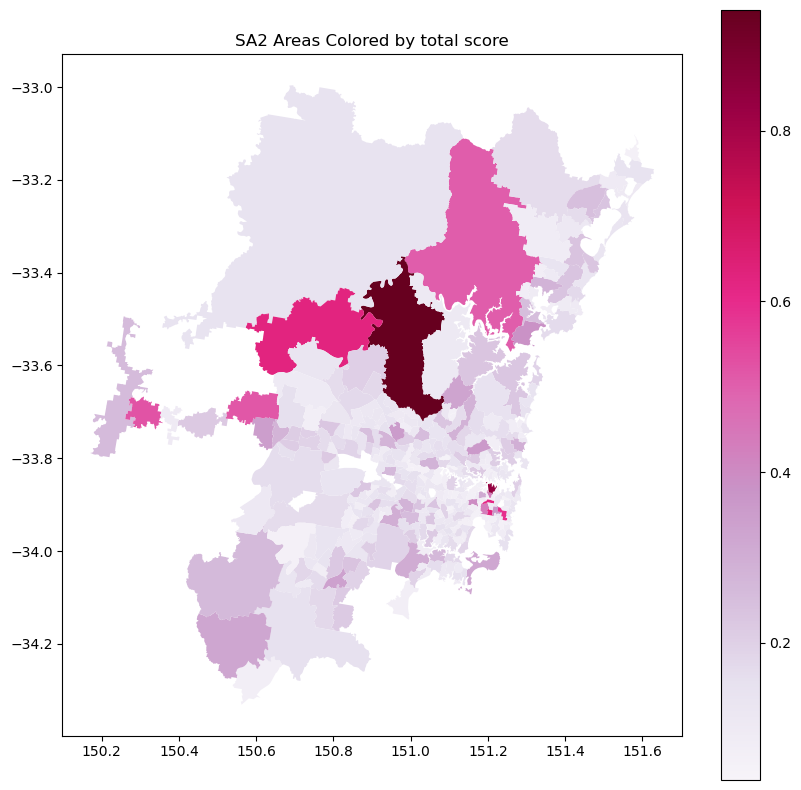

In [ ]:
### Create a map
import geopandas as gpd
import matplotlib.pyplot as plt

cmap = 'PuRd'

result = gpd.read_postgis("SELECT sa2_name_x, total_score,geom FROM extended_scores_geom", conn, crs=4326)

result.plot(column='total_score', cmap=cmap, figsize=(10, 10), legend=True)

plt.title('SA2 Areas Colored by total score')

plt.show()

In [ ]:
### Create a table
sql = """
SELECT
    MIN(total_score) AS Minimun,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total_score) AS Q1,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total_score) AS Median,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_score) AS Q3,
    Max(total_score) As Maximum
FROM extended_scores;
"""
query(conn, sql)

,minimun,q1,median,q3,maximum
0,0.038799,0.098338,0.132386,0.177775,0.941803


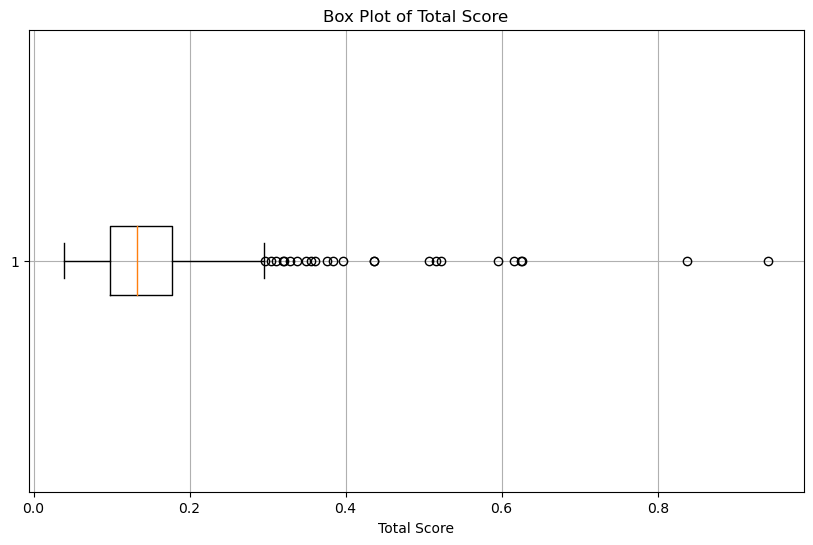

In [ ]:
### Create a box plot
plt.figure(figsize=(10, 6))
plt.boxplot(result['total_score'], vert=False)
plt.xlabel('Total Score')
plt.title('Box Plot of Total Score')
plt.grid(True)
plt.show()

In [ ]:
## Correlation Determination
income_query = "SELECT sa2_code21, median_income FROM income"
income_df = pd.read_sql_query(income_query, conn)

query = """
SELECT
    scores.*,
    income.median_income
FROM
    extended_scores AS scores
JOIN
    income ON scores.sa2_code = income.sa2_code21;
"""
extended_scores_with_income = pd.read_sql_query(query, conn)
extended_scores_with_income

,sa2_code,sa2_name_x,total_score,median_income
0,115021297,Dural - Kenthurst - Wisemans Ferry,0.941803,58477
1,117031644,Sydney (North) - Millers Point,0.837322,62966
2,117031643,Rosebery - Beaconsfield,0.626056,68972
3,115031300,Kurrajong Heights - Ebenezer,0.624554,58312
4,117031642,Redfern,0.615537,70057
...,...,...,...,...
355,117031641,Pyrmont,0.055643,65158
356,119021659,Campsie - North,0.055564,40777
357,126021722,Denistone,0.055557,58124
358,117031639,Chippendale,0.045068,47437


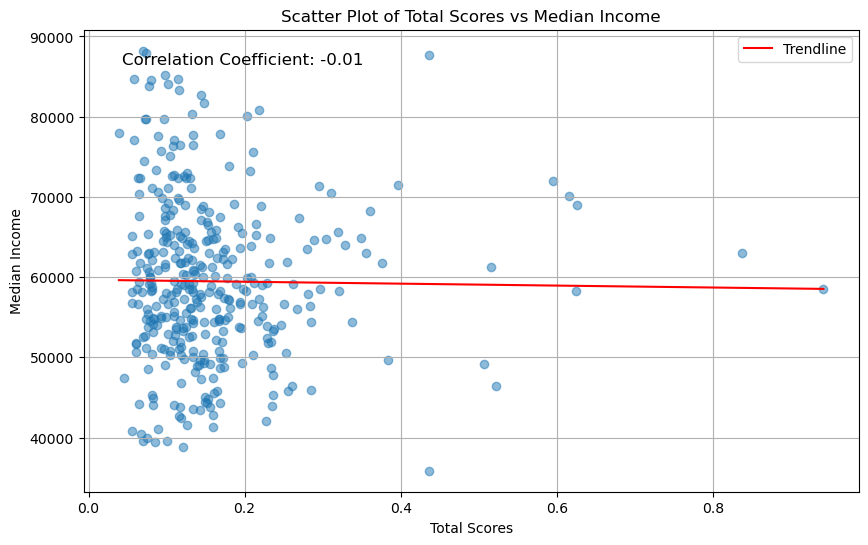

In [ ]:
### create a scatter plot
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

x = extended_scores_with_income['total_score']
y = extended_scores_with_income['median_income']
slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)
plt.title('Scatter Plot of Total Scores vs Median Income')
plt.xlabel('Total Scores')
plt.ylabel('Median Income')
plt.grid(True)

plt.plot(x, slope * x + intercept, color='red', label='Trendline')
plt.text(0.05, 0.95, f'Correlation Coefficient: {r_value:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.legend()
plt.show()